#  TF-IDF Analysis
## Pengaruh TikTok Shop terhadap UMKM di Indonesia

### Analisis mencakup:
1. TF-IDF Keseluruhan (Overall)
2. TF-IDF berdasarkan **Kanal Berita** (category)
3. TF-IDF berdasarkan **Time Frame** (bulanan & kuartal)
4. TF-IDF berdasarkan **Tipe Sumber** (source/portal berita)
5. TF-IDF dengan **POS Analysis** (filter Noun & Verb)
6. TF-IDF dengan **NER Analysis** (Named Entity Recognition)
7. **N-Grams Analysis** (Bigram & Trigram)

In [1]:
# Install dependencies
%pip install scikit-learn matplotlib seaborn tqdm spacy --quiet
!python -m spacy download en_core_web_sm --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 91.8 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [2]:
# Import libraries
import os
import ast
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from collections import Counter
from tqdm import tqdm
import spacy

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
tqdm.pandas()

# Load spaCy model untuk POS & NER
nlp = spacy.load('en_core_web_sm')

print('✅ Semua library berhasil diimport.')

✅ Semua library berhasil diimport.


In [3]:
# Load dataset preprocessed
csv_path = '/content/scraped_articles_preprocessed.csv'  # Ganti path jika berbeda

df = pd.read_csv(csv_path, low_memory=False)
df['published'] = pd.to_datetime(df['published'], errors='coerce')

print('✅ Dataset berhasil dimuat!')
print(f'   Shape : {df.shape}')
print(f'   Kolom : {df.columns.tolist()}')
print(f'   Rentang tanggal: {df["published"].min()} s/d {df["published"].max()}')
display(df.head(3))

✅ Dataset berhasil dimuat!
   Shape : (804, 13)
   Kolom : ['title', 'source', 'link asli', 'published', 'content', 'category', 'sentimen', 'scrape_status', 'content_cleaned', 'tokenization', 'stopword_removed', 'stemming_output', 'stemming_cleaned']
   Rentang tanggal: 2016-11-24 08:00:00 s/d 2026-04-14 11:19:15


,title,source,link asli,published,content,category,sentimen,scrape_status,content_cleaned,tokenization,stopword_removed,stemming_output,stemming_cleaned
0,TikTok raises minimum user age in Indonesia fo...,ANTARA News Bali,https://bali.antaranews.com/berita/403417/tikt...,2026-04-14 11:19:15,Jakarta (ANTARA) -\nSocial media giant TikTok ...,Regulasi,Netral,Success,social media giant tiktok announced that it ha...,"['social', 'media', 'giant', 'tiktok', 'announ...","['social', 'media', 'giant', 'tiktok', 'announ...","['social', 'media', 'giant', 'tiktok', 'announ...","['social', 'media', 'giant', 'tiktok', 'that',..."
1,TikTok Indonesia Resmi Umumkan Tutup Fitur Tik...,Jawa Pos,https://www.jawapos.com/aplikasi/2310040011/ti...,2026-04-12 16:57:43,Fitur TikTok Shop resmi ditutup hari ini./\nJa...,Isu,Negatif,Success,tiktokshop mulai hari ini rabu tepatnya pada p...,"['tiktokshop', 'mulai', 'hari', 'ini', 'rabu',...","['tiktokshop', 'rabu', 'tepatnya', 'wib', 'res...","['tiktokshop', 'rabu', 'tepat', 'wib', 'resmi'...","['tiktokshop', 'rabu', 'tepat', 'wib', 'resmi'..."
2,LIVE Tokopedia–TikTok Shop Ditonton 38 Miliar ...,SWA.co.id,https://swa.co.id/read/471326/live-tokopediati...,2026-04-12 14:45:00,Kementerian Perdagangan mencatat nilai penjual...,Bisnis,Positif,Success,kementerian perdagangan mencatat nilai penjual...,"['kementerian', 'perdagangan', 'mencatat', 'ni...","['kementerian', 'perdagangan', 'mencatat', 'ni...","['menteri', 'dagang', 'catat', 'nilai', 'jual'...","['menteri', 'dagang', 'catat', 'nilai', 'jual'..."


In [4]:
# Persiapan kolom teks & tambahan fitur waktu

# --- Fungsi konversi kolom list-string -> string ---
def list_str_to_text(val):
    """Konversi kolom bertipe string representasi list menjadi string biasa."""
    if pd.isna(val) or val == '':
        return ''
    try:
        tokens = ast.literal_eval(str(val))
        return ' '.join(tokens)
    except Exception:
        return str(val)

# Kolom teks utama yang akan digunakan (prioritas: stemming_cleaned > stopword_removed > content_cleaned)
print('Menyiapkan kolom teks...')
df['text_stemmed']    = df['stemming_cleaned'].progress_apply(list_str_to_text)
df['text_stopremoved']= df['stopword_removed'].progress_apply(list_str_to_text)

# Pilih kolom utama
TEXT_COL = 'text_stemmed'  # Kolom utama untuk TF-IDF
print(f'\n✅ Kolom teks utama: {TEXT_COL}')

# --- Tambahan fitur waktu ---
df['year']    = df['published'].dt.year
df['month']   = df['published'].dt.month
df['month_label'] = df['published'].dt.strftime('%Y-%m')

def get_quarter(row):
    """Label kuartal berdasarkan bulan."""
    m = row['month']
    y = row['year']
    if pd.isna(m) or pd.isna(y):
        return 'Unknown'
    q = (int(m) - 1) // 3 + 1
    return f'{int(y)}-Q{q}'

df['quarter'] = df.apply(get_quarter, axis=1)

print('\n📋 Distribusi kategori:')
print(df['category'].value_counts())
print('\n📋 Distribusi sentimen:')
print(df['sentimen'].value_counts())
print('\n📋 Distribusi per kuartal (top 10):')
print(df['quarter'].value_counts().head(10))
print(f'\n✅ Persiapan data selesai. Total artikel: {len(df)}')

Menyiapkan kolom teks...


100%|██████████| 804/804 [00:00<00:00, 1054.58it/s]


✅ Kolom teks utama: text_stemmed

📋 Distribusi kategori:
category
Isu         251
Regulasi    188
Bisnis      132
Strategi     92
Edukasi      89
Event        52
Name: count, dtype: int64

📋 Distribusi sentimen:
sentimen
Positif    304
Negatif    267
Netral     233
Name: count, dtype: int64

📋 Distribusi per kuartal (top 10):
quarter
2023-Q4    177
2023-Q3    158
2026-Q1     89
2025-Q4     72
2025-Q3     70
2025-Q2     67
2024-Q1     34
2026-Q2     19
2025-Q1     16
2024-Q3     15
Name: count, dtype: int64

✅ Persiapan data selesai. Total artikel: 804


In [5]:
# Cell 5: Setup direktori output
os.makedirs('/content/data',    exist_ok=True)
os.makedirs('/content/figures', exist_ok=True)

print('✅ Direktori output siap:')
print('   /content/data    -> file CSV hasil TF-IDF')
print('   /content/figures -> file PNG visualisasi')

✅ Direktori output siap:
   /content/data    -> file CSV hasil TF-IDF
   /content/figures -> file PNG visualisasi


In [6]:
# Fungsi helper TF-IDF & visualisasi
def compute_tfidf_top(corpus, top_n=20, ngram_range=(1,1), min_df=2, max_features=5000):
    """
    Hitung TF-IDF pada corpus dan kembalikan top_n term.
    Returns: DataFrame dengan kolom 'term' dan 'mean_tfidf'
    """
    corpus = [str(t) for t in corpus if str(t).strip() != '']
    if len(corpus) < 2:
        return pd.DataFrame(columns=['term','mean_tfidf'])

    actual_min_df = min(min_df, max(1, len(corpus) // 5))

    vec = TfidfVectorizer(
        max_features=max_features,
        ngram_range=ngram_range,
        min_df=actual_min_df
    )
    X = vec.fit_transform(corpus)
    feature_names = vec.get_feature_names_out()
    mean_scores   = np.asarray(X.mean(axis=0)).ravel()
    top_idx       = mean_scores.argsort()[::-1][:top_n]

    return pd.DataFrame({
        'term'      : feature_names[top_idx],
        'mean_tfidf': mean_scores[top_idx]
    })


def plot_tfidf(df_top, title, fig_path=None, top_n=20, color='viridis'):
    """
    Bar chart horizontal untuk top TF-IDF terms.
    """
    df_plot = df_top.head(top_n).copy()
    plt.figure(figsize=(10, max(5, len(df_plot) * 0.4)))
    sns.barplot(y='term', x='mean_tfidf', data=df_plot, palette=color, orient='h')
    plt.title(title, fontsize=13, fontweight='bold', pad=12)
    plt.xlabel('Mean TF-IDF Score', fontsize=11)
    plt.ylabel('Term', fontsize=11)
    plt.tight_layout()
    if fig_path:
        plt.savefig(fig_path, dpi=150, bbox_inches='tight')
        print(f'   💾 Gambar: {fig_path}')
    plt.show()
    plt.close()


print('✅ Fungsi helper siap digunakan.')

✅ Fungsi helper siap digunakan.


---
## 1️⃣ TF-IDF Keseluruhan (Overall)

📊 TF-IDF KESELURUHAN (OVERALL)

📌 Top 30 Unigram – Overall:


,term,mean_tfidf
0,tiktokshop,0.067954
1,tiktok,0.067303
2,tokopedia,0.057873
3,jual,0.057249
4,umkm,0.051501
5,indonesia,0.048941
6,dagang,0.047516
7,produk,0.044067
8,usaha,0.042918
9,platform,0.037226


   💾 Gambar: /content/figures/tfidf_overall_unigram.png


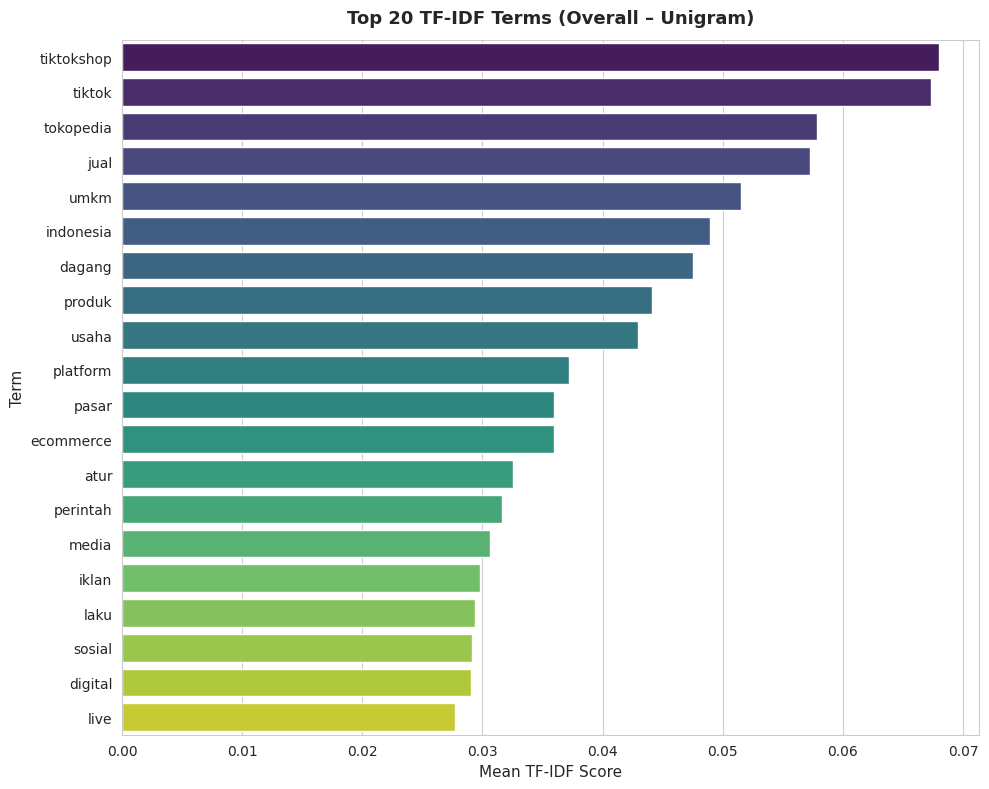


📌 Top 30 Bigram – Overall:


,term,mean_tfidf
0,media sosial,0.032256
1,tokopedia tiktokshop,0.026410
2,laku usaha,0.023675
3,social commerce,0.022827
4,laku umkm,0.018188
5,iklan iklan,0.017627
6,nyaman iklan,0.017392
7,iklan langgan,0.017392
8,langgan bisnispro,0.017392
9,menteri dagang,0.017354


   💾 Gambar: /content/figures/tfidf_overall_bigram.png


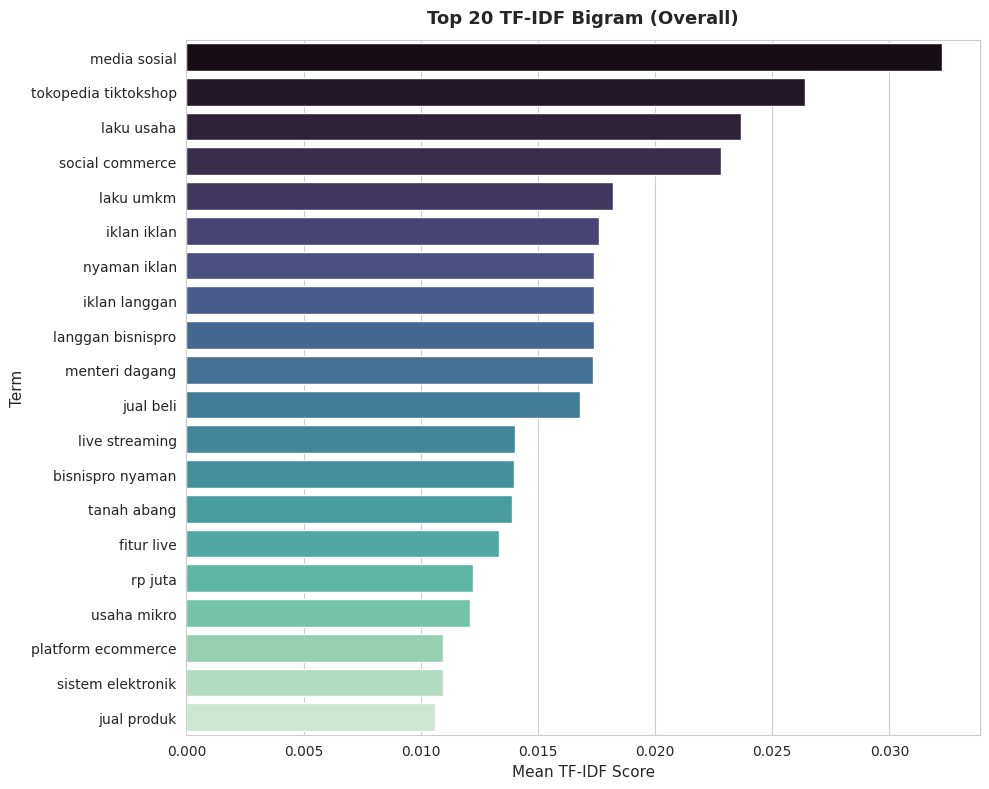


✅ TF-IDF Overall selesai.


In [7]:
# TF-IDF Overall (Unigram + Bigram)
print('=' * 55)
print('📊 TF-IDF KESELURUHAN (OVERALL)')
print('=' * 55)

corpus_all = df[TEXT_COL].fillna('').astype(str).tolist()

# --- Unigram ---
top_uni = compute_tfidf_top(corpus_all, top_n=30, ngram_range=(1,1), min_df=3)
top_uni.to_csv('/content/data/tfidf_overall_unigram.csv', index=False)
print('\n📌 Top 30 Unigram – Overall:')
display(top_uni)
plot_tfidf(top_uni, 'Top 20 TF-IDF Terms (Overall – Unigram)',
           fig_path='/content/figures/tfidf_overall_unigram.png', color='viridis')

# --- Bigram ---
top_bi = compute_tfidf_top(corpus_all, top_n=30, ngram_range=(2,2), min_df=3)
top_bi.to_csv('/content/data/tfidf_overall_bigram.csv', index=False)
print('\n📌 Top 30 Bigram – Overall:')
display(top_bi)
plot_tfidf(top_bi, 'Top 20 TF-IDF Bigram (Overall)',
           fig_path='/content/figures/tfidf_overall_bigram.png', color='mako')

print('\n✅ TF-IDF Overall selesai.')

---
## 2️⃣ TF-IDF berdasarkan Kanal Berita (Category)

📊 TF-IDF PER KANAL BERITA (CATEGORY)
Kategori ditemukan: ['Regulasi', 'Isu', 'Bisnis', 'Strategi', 'Event', 'Edukasi']


🔹 Kategori: Bisnis (132 artikel)


,term,mean_tfidf,category
0,tiktok,0.068597,Bisnis
1,tiktokshop,0.059926,Bisnis
2,tokopedia,0.055720,Bisnis
3,umkm,0.051425,Bisnis
4,jual,0.048369,Bisnis
5,produk,0.044698,Bisnis
6,indonesia,0.044341,Bisnis
7,usaha,0.037239,Bisnis
8,dagang,0.035290,Bisnis
9,platform,0.035244,Bisnis


   💾 Gambar: /content/figures/tfidf_kategori_bisnis.png


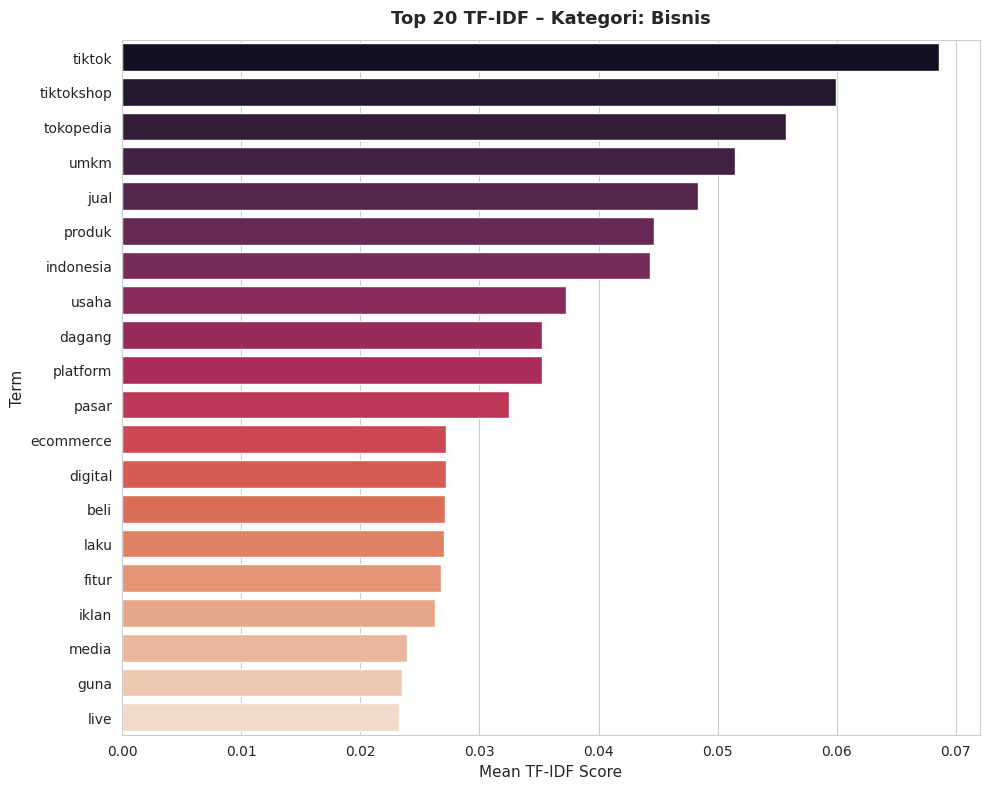


🔹 Kategori: Edukasi (89 artikel)


,term,mean_tfidf,category
0,tiktokshop,0.067325,Edukasi
1,tokopedia,0.058214,Edukasi
2,tiktok,0.052550,Edukasi
3,jual,0.051613,Edukasi
4,umkm,0.049126,Edukasi
5,live,0.048184,Edukasi
6,usaha,0.034721,Edukasi
7,konten,0.033979,Edukasi
8,produk,0.032636,Edukasi
9,indonesia,0.032188,Edukasi


   💾 Gambar: /content/figures/tfidf_kategori_edukasi.png


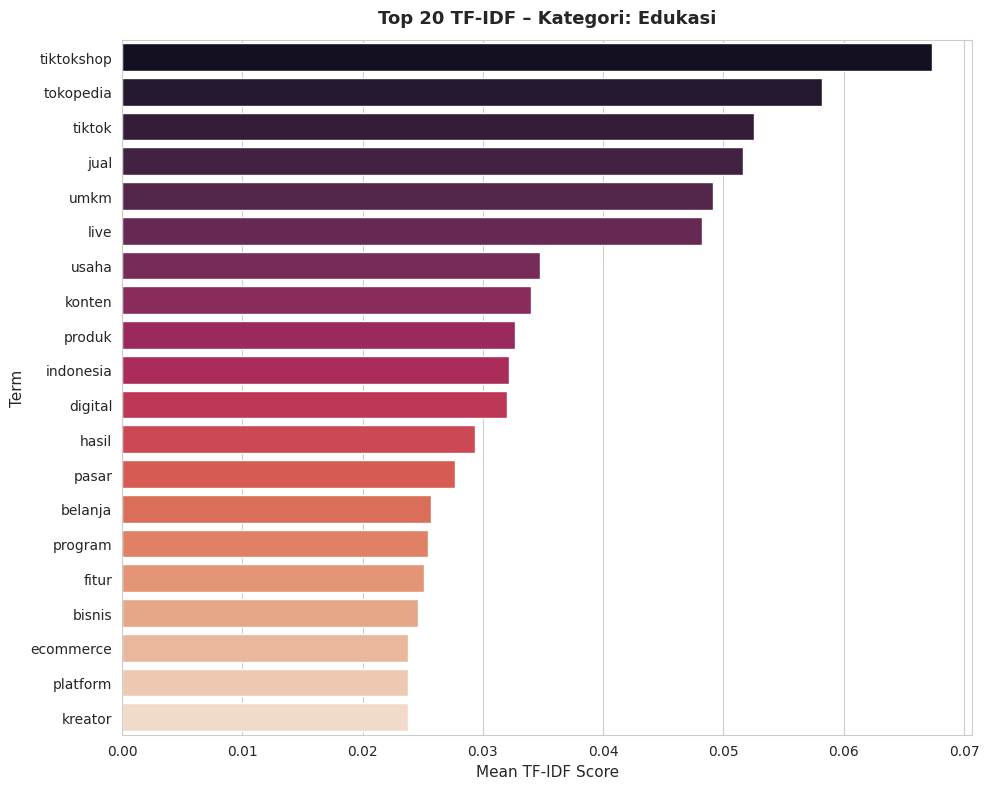


🔹 Kategori: Event (52 artikel)


,term,mean_tfidf,category
0,tokopedia,0.083753,Event
1,ramadan,0.073105,Event
2,tiktokshop,0.072110,Event
3,jual,0.059786,Event
4,tiktok,0.058963,Event
5,tokopedia tiktokshop,0.049193,Event
6,indonesia,0.046124,Event
7,lokal,0.043424,Event
8,umkm,0.039788,Event
9,tingkat,0.039385,Event


   💾 Gambar: /content/figures/tfidf_kategori_event.png


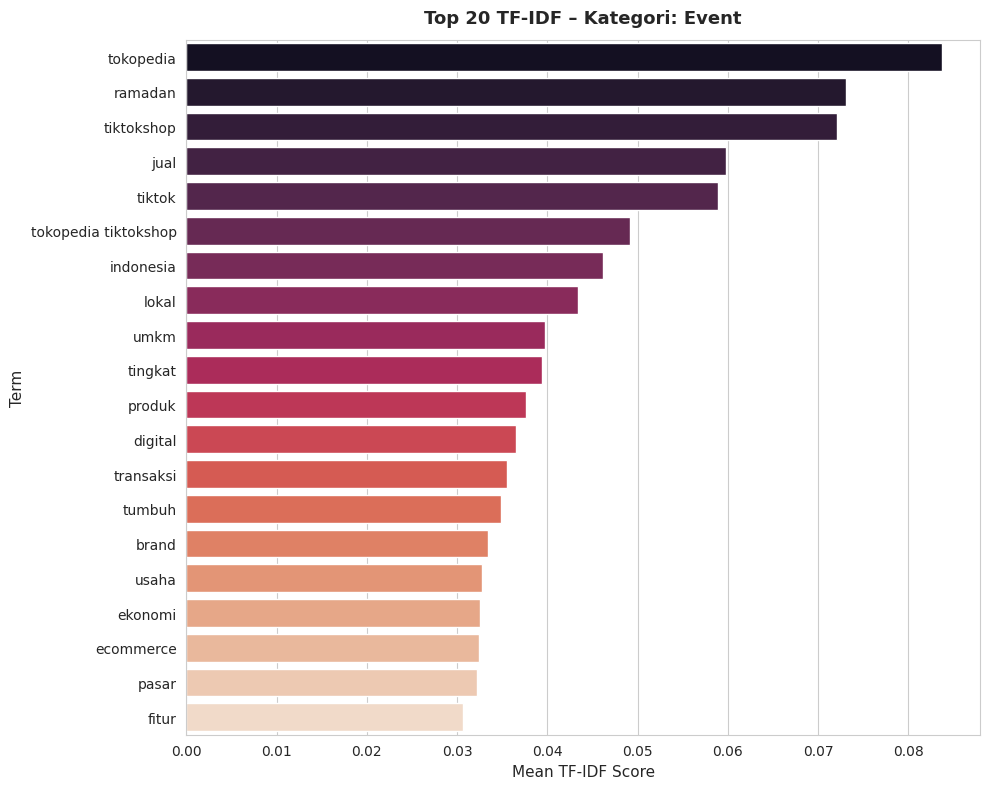


🔹 Kategori: Isu (251 artikel)


,term,mean_tfidf,category
0,tiktok,0.054448,Isu
1,tiktokshop,0.050711,Isu
2,jual,0.046512,Isu
3,indonesia,0.043102,Isu
4,dagang,0.042854,Isu
5,usaha,0.042556,Isu
6,umkm,0.041567,Isu
7,tokopedia,0.038962,Isu
8,produk,0.036109,Isu
9,pasar,0.033651,Isu


   💾 Gambar: /content/figures/tfidf_kategori_isu.png


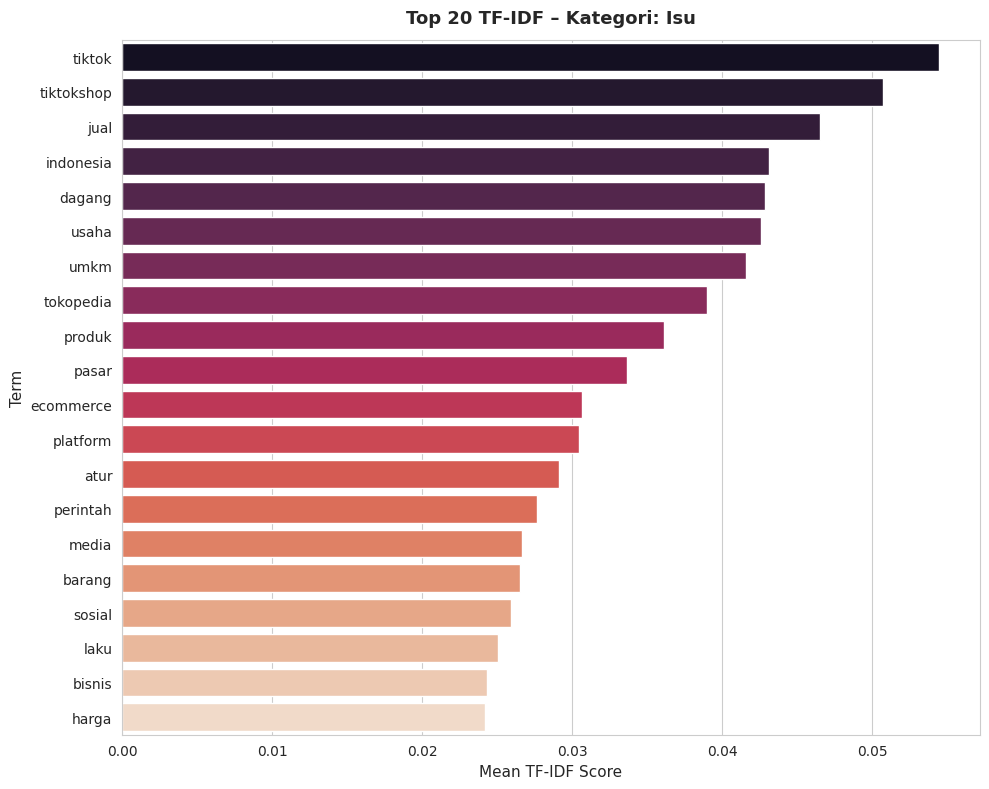


🔹 Kategori: Regulasi (188 artikel)


,term,mean_tfidf,category
0,tiktokshop,0.067021,Regulasi
1,tiktok,0.065709,Regulasi
2,jual,0.056558,Regulasi
3,dagang,0.054268,Regulasi
4,umkm,0.052987,Regulasi
5,indonesia,0.046152,Regulasi
6,tokopedia,0.045957,Regulasi
7,usaha,0.043029,Regulasi
8,atur,0.042092,Regulasi
9,produk,0.040972,Regulasi


   💾 Gambar: /content/figures/tfidf_kategori_regulasi.png


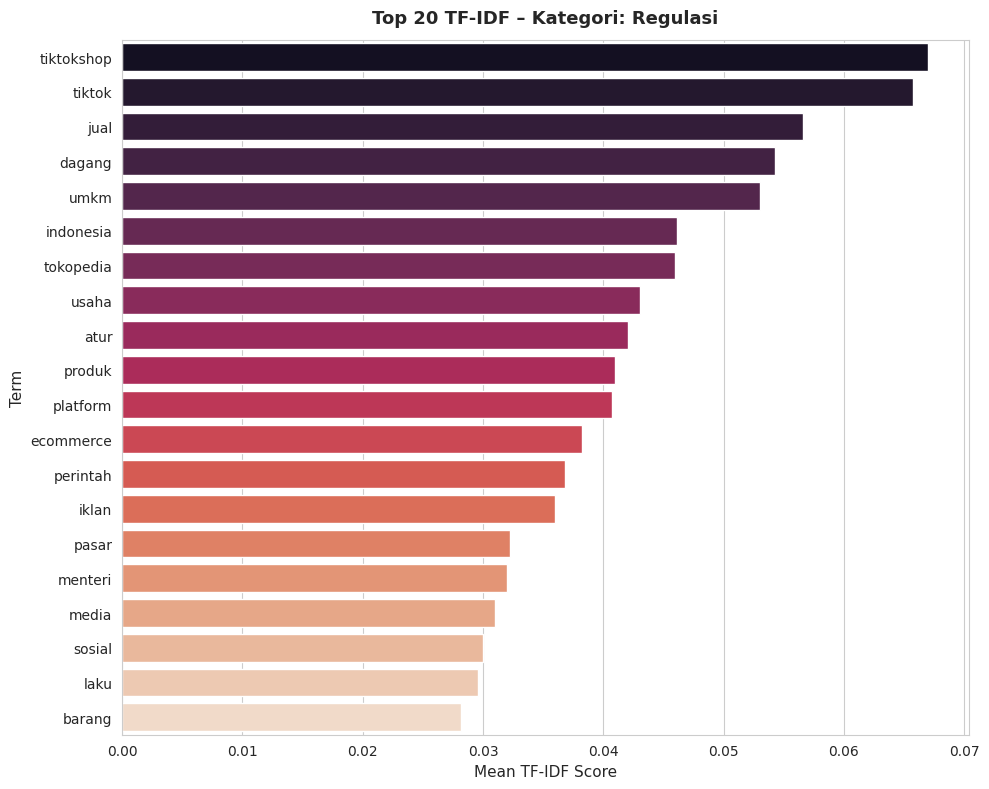


🔹 Kategori: Strategi (92 artikel)


,term,mean_tfidf,category
0,tiktok,0.061412,Strategi
1,tokopedia,0.059037,Strategi
2,tiktokshop,0.055752,Strategi
3,jual,0.052357,Strategi
4,produk,0.046612,Strategi
5,indonesia,0.045059,Strategi
6,umkm,0.042644,Strategi
7,pasar,0.032739,Strategi
8,usaha,0.032399,Strategi
9,guna,0.032035,Strategi


   💾 Gambar: /content/figures/tfidf_kategori_strategi.png


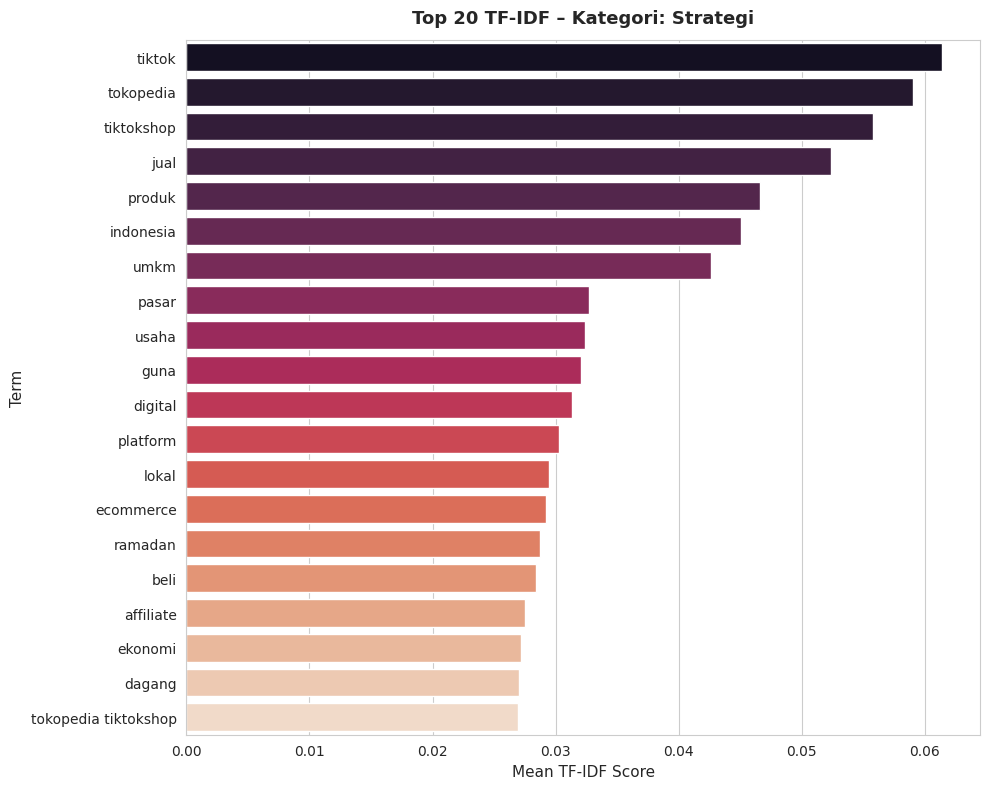


✅ Hasil per kategori disimpan ke: /content/data/tfidf_per_kategori.csv

📊 Heatmap Perbandingan TF-IDF Antar Kategori...


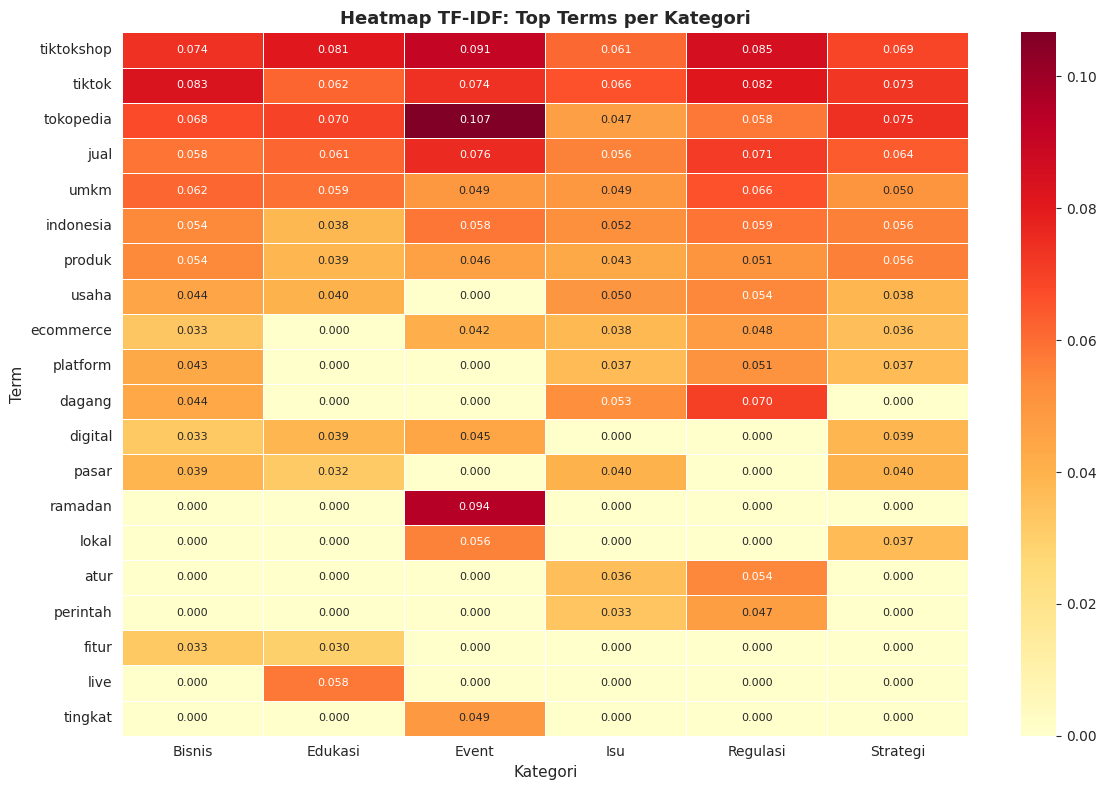

   💾 Gambar: /content/figures/tfidf_heatmap_kategori.png


In [8]:
# TF-IDF per Kanal Berita (Category)
print('=' * 55)
print('📊 TF-IDF PER KANAL BERITA (CATEGORY)')
print('=' * 55)

categories = df['category'].dropna().unique()
print(f'Kategori ditemukan: {list(categories)}\n')

all_cat_results = []

for cat in sorted(categories):
    subset = df[df['category'] == cat][TEXT_COL].fillna('').astype(str).tolist()
    if len(subset) < 3:
        print(f'⚠️  {cat}: terlalu sedikit data ({len(subset)}), dilewati.')
        continue

    print(f'\n🔹 Kategori: {cat} ({len(subset)} artikel)')
    top_cat = compute_tfidf_top(subset, top_n=20, ngram_range=(1,2), min_df=2)
    top_cat['category'] = cat
    all_cat_results.append(top_cat)

    display(top_cat.head(10))
    plot_tfidf(top_cat, f'Top 20 TF-IDF – Kategori: {cat}',
               fig_path=f'/content/figures/tfidf_kategori_{cat.lower()}.png', color='rocket')

# Simpan gabungan
if all_cat_results:
    df_cat_all = pd.concat(all_cat_results, ignore_index=True)
    df_cat_all.to_csv('/content/data/tfidf_per_kategori.csv', index=False)
    print('\n✅ Hasil per kategori disimpan ke: /content/data/tfidf_per_kategori.csv')

# --- Heatmap perbandingan top term antar kategori ---
print('\n📊 Heatmap Perbandingan TF-IDF Antar Kategori...')
pivot_data = {}
for cat in sorted(categories):
    subset = df[df['category'] == cat][TEXT_COL].fillna('').astype(str).tolist()
    if len(subset) < 3:
        continue
    top_cat = compute_tfidf_top(subset, top_n=15, ngram_range=(1,1), min_df=2)
    pivot_data[cat] = top_cat.set_index('term')['mean_tfidf']

if pivot_data:
    pivot_df = pd.DataFrame(pivot_data).fillna(0)
    # Ambil top 20 term berdasarkan total
    pivot_df = pivot_df.loc[pivot_df.sum(axis=1).nlargest(20).index]

    plt.figure(figsize=(12, 8))
    sns.heatmap(pivot_df, cmap='YlOrRd', linewidths=0.5,
                annot=True, fmt='.3f', annot_kws={'size': 8})
    plt.title('Heatmap TF-IDF: Top Terms per Kategori', fontsize=13, fontweight='bold')
    plt.xlabel('Kategori', fontsize=11)
    plt.ylabel('Term', fontsize=11)
    plt.tight_layout()
    plt.savefig('/content/figures/tfidf_heatmap_kategori.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    print('   💾 Gambar: /content/figures/tfidf_heatmap_kategori.png')

---
## 3️⃣ TF-IDF berdasarkan Time Frame (Bulanan & Kuartal)

📊 TF-IDF PER TIME FRAME (KUARTAL)
Artikel dengan tanggal valid: 804

Kuartal tersedia: ['2016-Q4', '2019-Q3', '2020-Q2', '2020-Q3', '2021-Q1', '2021-Q2', '2021-Q3', '2021-Q4', '2022-Q1', '2022-Q2', '2022-Q3', '2022-Q4', '2023-Q1', '2023-Q2', '2023-Q3', '2023-Q4', '2024-Q1', '2024-Q2', '2024-Q3', '2024-Q4', '2025-Q1', '2025-Q2', '2025-Q3', '2025-Q4', '2026-Q1', '2026-Q2']

✅ Hasil per kuartal disimpan ke: /content/data/tfidf_per_kuartal.csv

📊 Heatmap Top Terms per Kuartal...


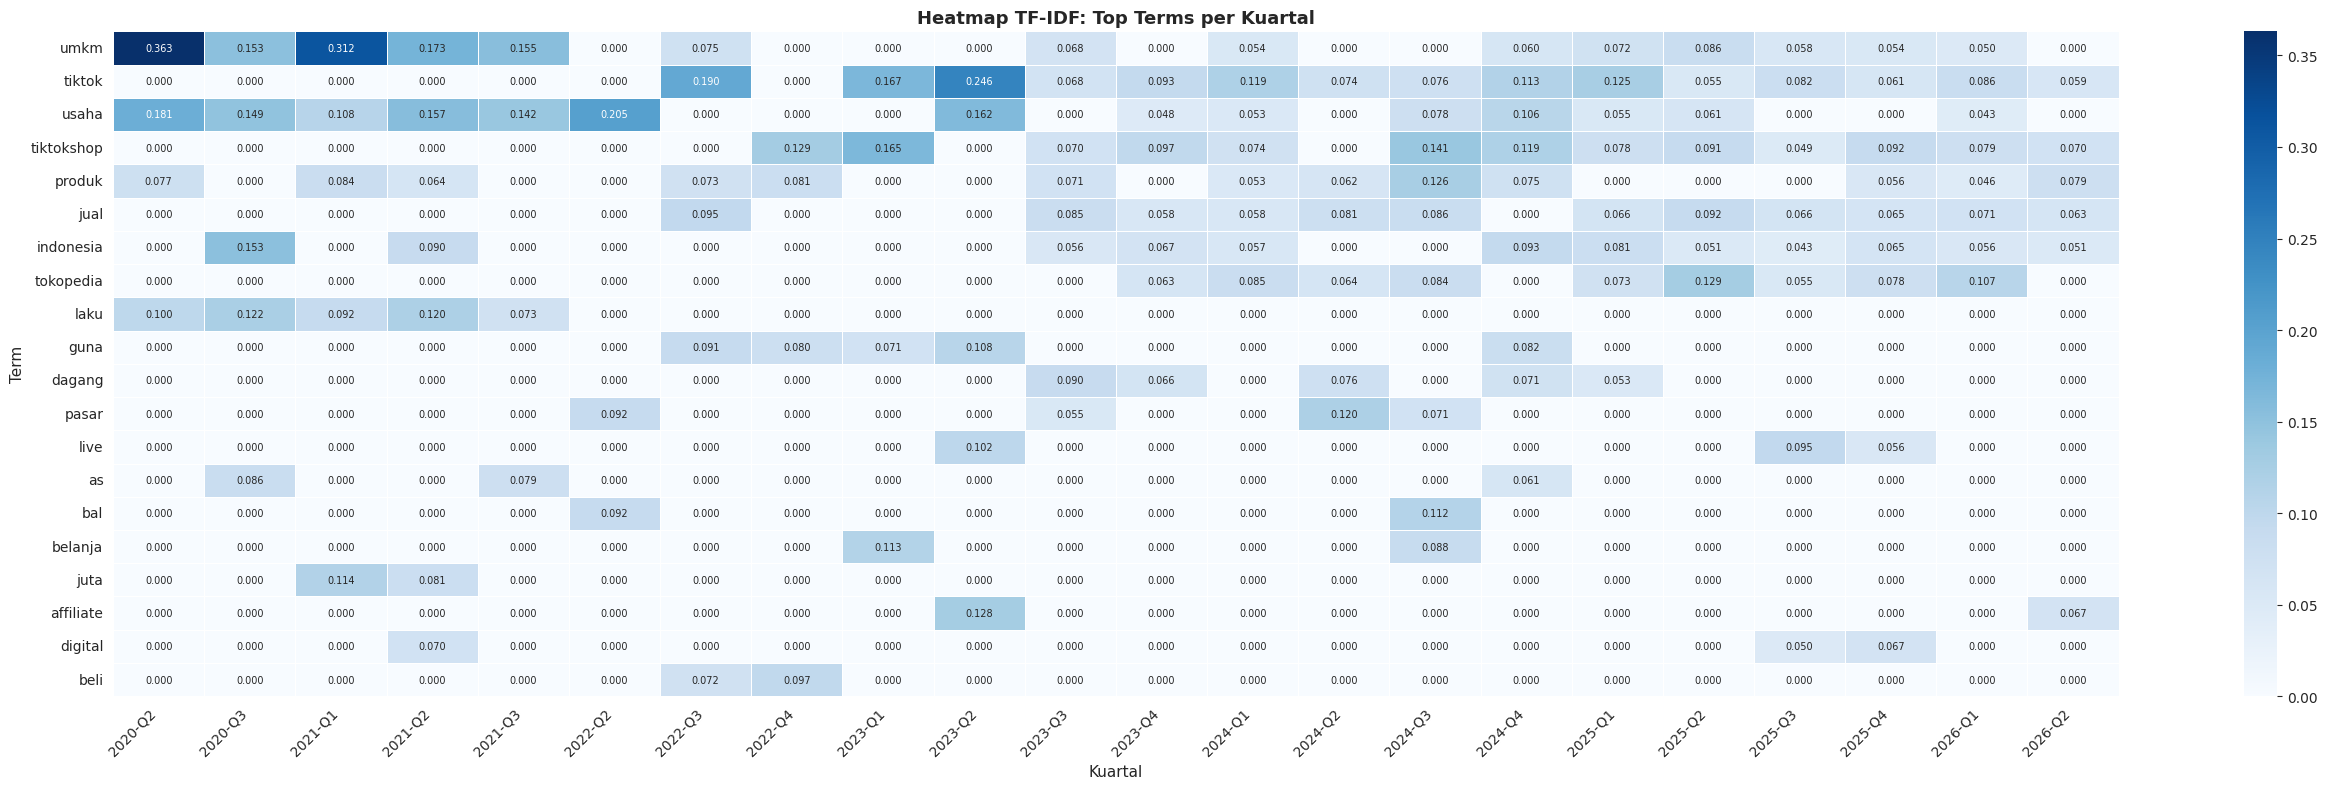

   💾 Gambar: /content/figures/tfidf_heatmap_kuartal.png


In [9]:
# TF-IDF per Time Frame (Kuartal)
print('=' * 55)
print('📊 TF-IDF PER TIME FRAME (KUARTAL)')
print('=' * 55)

# Filter data yang memiliki tanggal valid
df_dated = df[df['published'].notna()].copy()
print(f'Artikel dengan tanggal valid: {len(df_dated)}')

# --- Per Kuartal ---
quarters_sorted = sorted(df_dated['quarter'].unique())
print(f'\nKuartal tersedia: {quarters_sorted}')

quarter_results = []
for q in quarters_sorted:
    subset = df_dated[df_dated['quarter'] == q][TEXT_COL].fillna('').astype(str).tolist()
    if len(subset) < 3:
        continue
    top_q = compute_tfidf_top(subset, top_n=15, ngram_range=(1,2), min_df=2)
    top_q['quarter'] = q
    top_q['n_articles'] = len(subset)
    quarter_results.append(top_q)

if quarter_results:
    df_quarter_all = pd.concat(quarter_results, ignore_index=True)
    df_quarter_all.to_csv('/content/data/tfidf_per_kuartal.csv', index=False)
    print('\n✅ Hasil per kuartal disimpan ke: /content/data/tfidf_per_kuartal.csv')

# Visualisasi top 5 kata per kuartal (heatmap)
print('\n📊 Heatmap Top Terms per Kuartal...')
pivot_q = {}
for q in quarters_sorted:
    subset = df_dated[df_dated['quarter'] == q][TEXT_COL].fillna('').astype(str).tolist()
    if len(subset) < 3:
        continue
    top_q = compute_tfidf_top(subset, top_n=10, ngram_range=(1,1), min_df=2)
    pivot_q[q] = top_q.set_index('term')['mean_tfidf']

if pivot_q:
    pivot_q_df = pd.DataFrame(pivot_q).fillna(0)
    pivot_q_df = pivot_q_df.loc[pivot_q_df.sum(axis=1).nlargest(20).index]

    n_cols = len(pivot_q_df.columns)
    plt.figure(figsize=(max(10, n_cols * 1.2), 8))
    sns.heatmap(pivot_q_df, cmap='Blues', linewidths=0.4,
                annot=True, fmt='.3f', annot_kws={'size': 7})
    plt.title('Heatmap TF-IDF: Top Terms per Kuartal', fontsize=13, fontweight='bold')
    plt.xlabel('Kuartal', fontsize=11)
    plt.ylabel('Term', fontsize=11)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('/content/figures/tfidf_heatmap_kuartal.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    print('   💾 Gambar: /content/figures/tfidf_heatmap_kuartal.png')

📊 TF-IDF PER BULAN (6 Bulan Terakhir)
Bulan dianalisis: ['2025-11', '2025-12', '2026-01', '2026-02', '2026-03', '2026-04']

✅ Hasil per bulan disimpan ke: /content/data/tfidf_per_bulan.csv


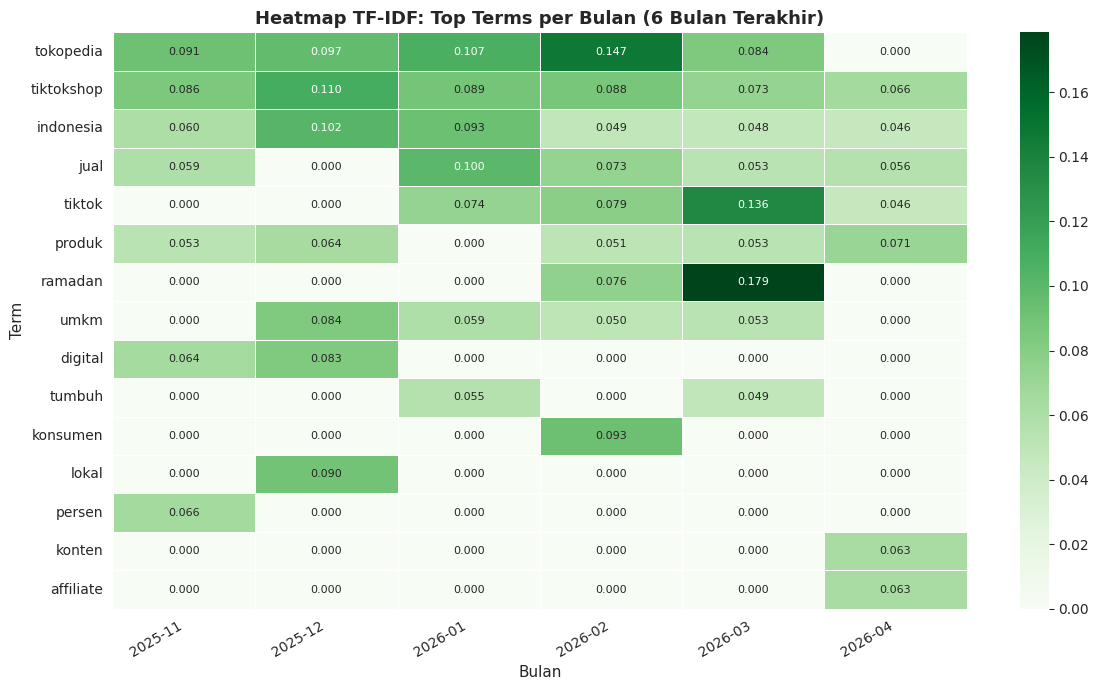

   💾 Gambar: /content/figures/tfidf_heatmap_bulanan.png


In [10]:
# TF-IDF per Bulan (6 bulan terakhir saja)
print('=' * 55)
print('📊 TF-IDF PER BULAN (6 Bulan Terakhir)')
print('=' * 55)

# Ambil 6 bulan terakhir yang ada di data
recent_months = sorted(df_dated['month_label'].dropna().unique())[-6:]
print(f'Bulan dianalisis: {recent_months}')

month_results = []
for m in recent_months:
    subset = df_dated[df_dated['month_label'] == m][TEXT_COL].fillna('').astype(str).tolist()
    if len(subset) < 2:
        continue
    top_m = compute_tfidf_top(subset, top_n=10, ngram_range=(1,1), min_df=1)
    top_m['month'] = m
    top_m['n_articles'] = len(subset)
    month_results.append(top_m)

if month_results:
    df_month_all = pd.concat(month_results, ignore_index=True)
    df_month_all.to_csv('/content/data/tfidf_per_bulan.csv', index=False)
    print('\n✅ Hasil per bulan disimpan ke: /content/data/tfidf_per_bulan.csv')

    # Visualisasi: grouped bar chart
    # Ambil 1 term teratas per bulan untuk trending view
    top1_per_month = df_month_all.groupby('month').first().reset_index()

    pivot_m = {}
    for m in recent_months:
        sub = df_month_all[df_month_all['month'] == m].set_index('term')['mean_tfidf']
        pivot_m[m] = sub

    pivot_m_df = pd.DataFrame(pivot_m).fillna(0)
    pivot_m_df = pivot_m_df.loc[pivot_m_df.sum(axis=1).nlargest(15).index]

    plt.figure(figsize=(12, 7))
    sns.heatmap(pivot_m_df, cmap='Greens', linewidths=0.4,
                annot=True, fmt='.3f', annot_kws={'size': 8})
    plt.title('Heatmap TF-IDF: Top Terms per Bulan (6 Bulan Terakhir)',
              fontsize=13, fontweight='bold')
    plt.xlabel('Bulan', fontsize=11)
    plt.ylabel('Term', fontsize=11)
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.savefig('/content/figures/tfidf_heatmap_bulanan.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    print('   💾 Gambar: /content/figures/tfidf_heatmap_bulanan.png')

---
## 4️⃣ TF-IDF berdasarkan Tipe Sumber (Source/Portal Berita)

📊 TF-IDF PER TIPE SUMBER (TOP 8 PORTAL)
Sumber dianalisis: ['Tempo.co', 'Kompas.com', 'CNN Indonesia', 'Kompasiana.com', 'Liputan6.com', 'Bisnis.com', 'Bloomberg Technoz', 'CNBC Indonesia']

🔹 Sumber: Tempo.co (47 artikel)


,term,mean_tfidf,source
0,iklan,0.128864,Tempo.co
1,tiktokshop,0.086578,Tempo.co
2,iklan iklan,0.076694,Tempo.co
3,tiktok,0.074941,Tempo.co
4,tokopedia,0.073581,Tempo.co


🔹 Sumber: Kompas.com (45 artikel)


,term,mean_tfidf,source
0,tiktokshop,0.091273,Kompas.com
1,tiktok,0.084129,Kompas.com
2,tokopedia,0.081730,Kompas.com
3,jual,0.067491,Kompas.com
4,produk,0.061572,Kompas.com


🔹 Sumber: CNN Indonesia (36 artikel)


...

🔹 Sumber: Bloomberg Technoz (25 artikel)


,term,mean_tfidf,source
0,tokopedia,0.072827,Bloomberg Technoz
1,harga,0.071226,Bloomberg Technoz
2,tiktokshop,0.069492,Bloomberg Technoz
3,jual,0.067410,Bloomberg Technoz
4,us,0.064849,Bloomberg Technoz


🔹 Sumber: CNBC Indonesia (24 artikel)


,term,mean_tfidf,source
0,tiktok,0.162595,CNBC Indonesia
1,tokopedia,0.110765,CNBC Indonesia
2,indonesia,0.097734,CNBC Indonesia
3,jual,0.068691,CNBC Indonesia
4,usaha,0.062837,CNBC Indonesia



✅ Hasil per sumber disimpan ke: /content/data/tfidf_per_sumber.csv

📊 Heatmap TF-IDF per Sumber...


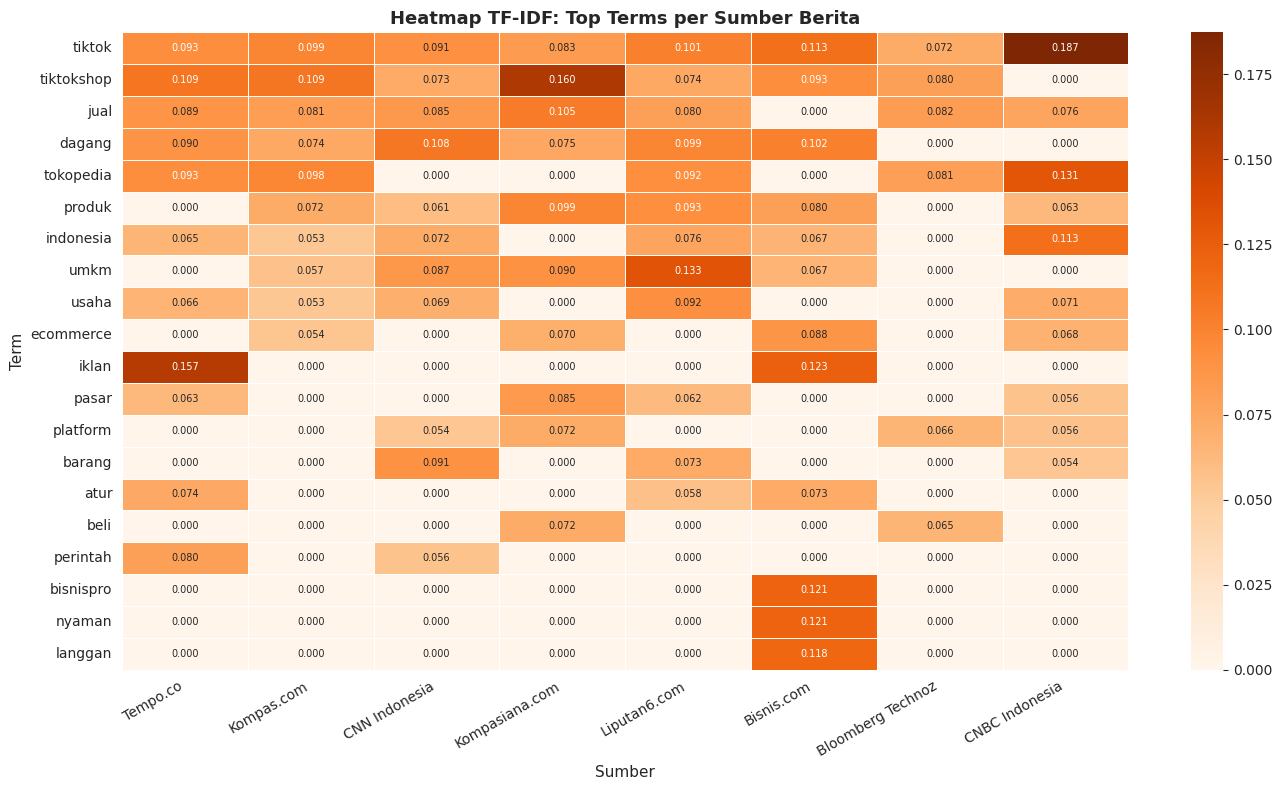

   💾 Gambar: /content/figures/tfidf_heatmap_sumber.png


In [11]:
# TF-IDF per Tipe Sumber (Top 8 Portal)
print('=' * 55)
print('📊 TF-IDF PER TIPE SUMBER (TOP 8 PORTAL)')
print('=' * 55)

# Ambil 8 sumber terbanyak
top_sources = df['source'].value_counts().head(8).index.tolist()
print(f'Sumber dianalisis: {top_sources}\n')

source_results = []
for src in top_sources:
    subset = df[df['source'] == src][TEXT_COL].fillna('').astype(str).tolist()
    if len(subset) < 3:
        continue
    print(f'🔹 Sumber: {src} ({len(subset)} artikel)')
    top_src = compute_tfidf_top(subset, top_n=15, ngram_range=(1,2), min_df=2)
    top_src['source'] = src
    source_results.append(top_src)
    display(top_src.head(5))

if source_results:
    df_src_all = pd.concat(source_results, ignore_index=True)
    df_src_all.to_csv('/content/data/tfidf_per_sumber.csv', index=False)
    print('\n✅ Hasil per sumber disimpan ke: /content/data/tfidf_per_sumber.csv')

# Heatmap sumber
print('\n📊 Heatmap TF-IDF per Sumber...')
pivot_src = {}
for src in top_sources:
    subset = df[df['source'] == src][TEXT_COL].fillna('').astype(str).tolist()
    if len(subset) < 3:
        continue
    top_src = compute_tfidf_top(subset, top_n=12, ngram_range=(1,1), min_df=2)
    pivot_src[src] = top_src.set_index('term')['mean_tfidf']

if pivot_src:
    pivot_src_df = pd.DataFrame(pivot_src).fillna(0)
    pivot_src_df = pivot_src_df.loc[pivot_src_df.sum(axis=1).nlargest(20).index]

    plt.figure(figsize=(14, 8))
    sns.heatmap(pivot_src_df, cmap='Oranges', linewidths=0.4,
                annot=True, fmt='.3f', annot_kws={'size': 7})
    plt.title('Heatmap TF-IDF: Top Terms per Sumber Berita', fontsize=13, fontweight='bold')
    plt.xlabel('Sumber', fontsize=11)
    plt.ylabel('Term', fontsize=11)
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.savefig('/content/figures/tfidf_heatmap_sumber.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    print('   💾 Gambar: /content/figures/tfidf_heatmap_sumber.png')

---
## 5️⃣ TF-IDF dengan POS Analysis (Part-of-Speech Filtering)

📊 TF-IDF + POS ANALYSIS
Mengekstrak token per POS tag (ini mungkin memakan waktu)...
Memproses POS tagging (Noun/PropNoun)...


100%|██████████| 300/300 [00:26<00:00, 11.25it/s]


Memproses POS tagging (Verb)...


100%|██████████| 300/300 [00:27<00:00, 11.08it/s]


Memproses POS tagging (Adjective)...


100%|██████████| 300/300 [00:25<00:00, 11.63it/s]



🔹 POS: Noun (NOUN/PROPN) (300 dokumen)


,term,mean_tfidf,pos_type
0,yang,0.114962,Noun (NOUN/PROPN)
1,dan,0.108786,Noun (NOUN/PROPN)
2,di,0.060037,Noun (NOUN/PROPN)
3,tokopedia,0.057071,Noun (NOUN/PROPN)
4,tiktokshop,0.056950,Noun (NOUN/PROPN)
5,tiktok,0.055673,Noun (NOUN/PROPN)
6,ini,0.055091,Noun (NOUN/PROPN)
7,untuk,0.053276,Noun (NOUN/PROPN)
8,dengan,0.049430,Noun (NOUN/PROPN)
9,umkm,0.047791,Noun (NOUN/PROPN)


   💾 Gambar: /content/figures/tfidf_pos_noun.png


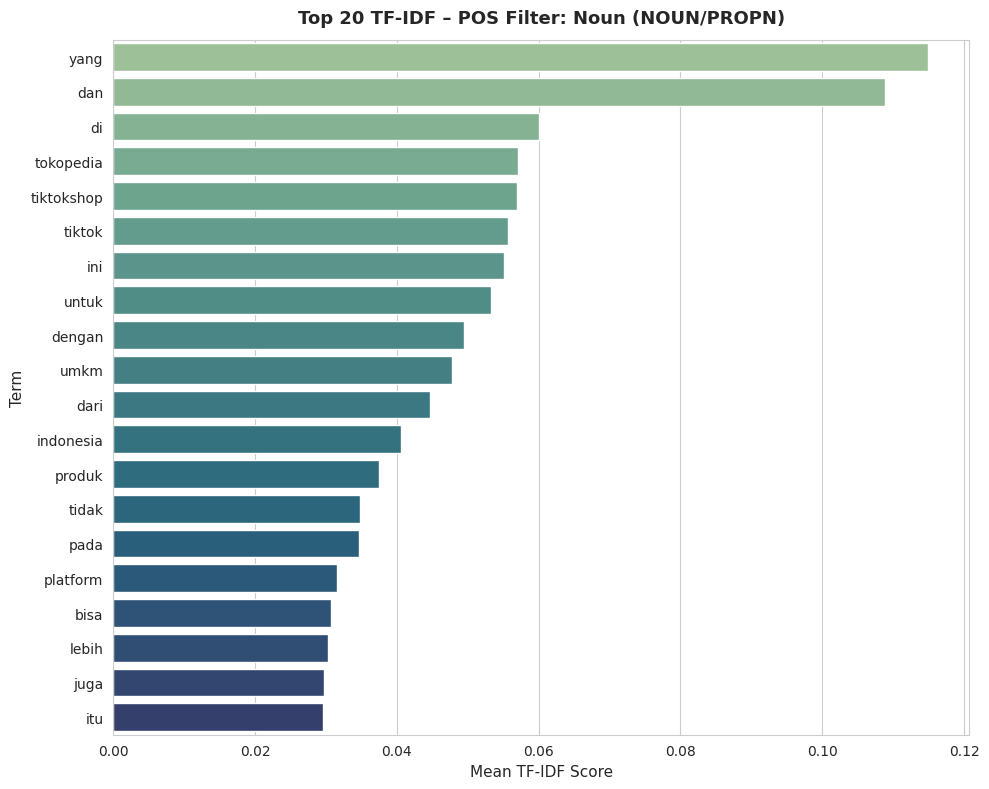


🔹 POS: Verb (VERB) (285 dokumen)


,term,mean_tfidf,pos_type
0,dalam,0.182168,Verb (VERB)
1,konten,0.115318,Verb (VERB)
2,pasar,0.073610,Verb (VERB)
3,ecommerce,0.063191,Verb (VERB)
4,sebagai,0.051144,Verb (VERB)
5,paling,0.047639,Verb (VERB)
6,bersaing,0.046488,Verb (VERB)
7,penting,0.044947,Verb (VERB)
8,mereka,0.040600,Verb (VERB)
9,live,0.038376,Verb (VERB)


   💾 Gambar: /content/figures/tfidf_pos_verb.png


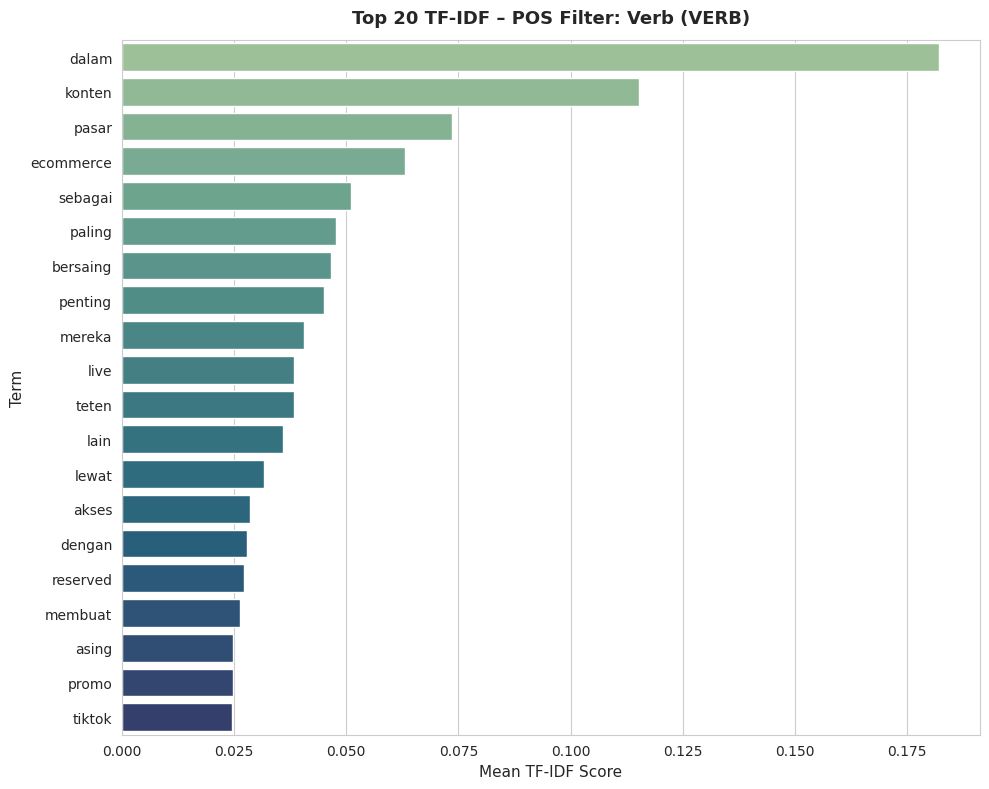


🔹 POS: Adjective (ADJ) (276 dokumen)


,term,mean_tfidf,pos_type
0,sosial,0.162914,Adjective (ADJ)
1,penjual,0.069340,Adjective (ADJ)
2,live,0.055259,Adjective (ADJ)
3,satu,0.052626,Adjective (ADJ)
4,mengatakan,0.046067,Adjective (ADJ)
5,digital,0.039164,Adjective (ADJ)
6,akan,0.038931,Adjective (ADJ)
7,berikut,0.028498,Adjective (ADJ)
8,menjual,0.028127,Adjective (ADJ)
9,dari,0.024290,Adjective (ADJ)


   💾 Gambar: /content/figures/tfidf_pos_adjective.png


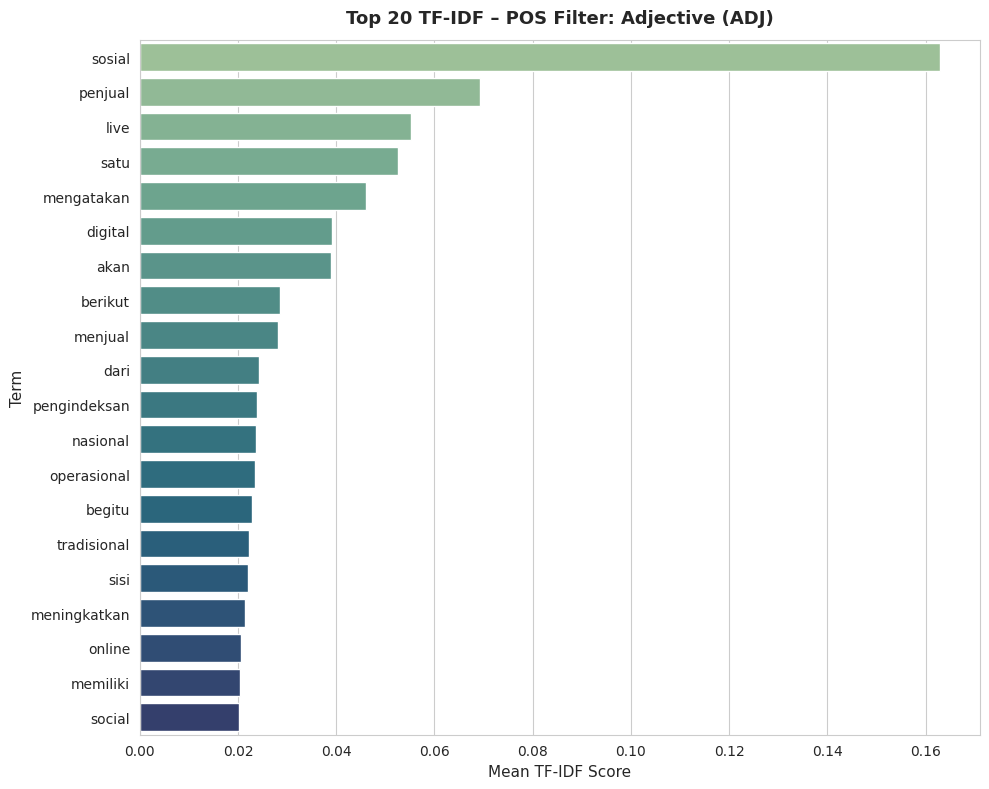


✅ Hasil POS analysis disimpan ke: /content/data/tfidf_pos_analysis.csv


In [12]:
# TF-IDF + POS Analysis
# Filter berdasarkan jenis kata: Noun (NOUN), Verb (VERB),
# Adjective (ADJ)
print('=' * 55)
print('📊 TF-IDF + POS ANALYSIS')
print('=' * 55)

# Gunakan content_cleaned (teks bahasa Indonesia lebih lengkap)
# spaCy memproses teks Inggris – gunakan content_cleaned yang sudah lowercase
print('Mengekstrak token per POS tag (ini mungkin memakan waktu)...')

def extract_pos_tokens(text, allowed_pos=('NOUN', 'PROPN')):
    """Ekstrak token berdasarkan POS tag menggunakan spaCy."""
    if not text or str(text).strip() == '':
        return ''
    doc = nlp(str(text)[:500000])  # batasi panjang teks
    tokens = [token.text.lower() for token in doc
              if token.pos_ in allowed_pos
              and not token.is_stop
              and token.is_alpha
              and len(token.text) > 1]
    return ' '.join(tokens)

# Gunakan sample representatif (max 300 artikel) agar tidak terlalu lama
sample_df = df.sample(min(300, len(df)), random_state=42).copy()
corpus_for_pos = sample_df['content_cleaned'].fillna('').astype(str).tolist()

print('Memproses POS tagging (Noun/PropNoun)...')
noun_texts = [extract_pos_tokens(t, allowed_pos=('NOUN','PROPN')) for t in tqdm(corpus_for_pos)]
print('Memproses POS tagging (Verb)...')
verb_texts = [extract_pos_tokens(t, allowed_pos=('VERB',)) for t in tqdm(corpus_for_pos)]
print('Memproses POS tagging (Adjective)...')
adj_texts  = [extract_pos_tokens(t, allowed_pos=('ADJ',)) for t in tqdm(corpus_for_pos)]

# --- TF-IDF per POS ---
pos_groups = {
    'Noun (NOUN/PROPN)' : noun_texts,
    'Verb (VERB)'       : verb_texts,
    'Adjective (ADJ)'   : adj_texts,
}

pos_results = []
for pos_label, texts in pos_groups.items():
    texts_clean = [t for t in texts if t.strip() != '']
    if len(texts_clean) < 3:
        print(f'⚠️  {pos_label}: data tidak cukup, dilewati.')
        continue
    print(f'\n🔹 POS: {pos_label} ({len(texts_clean)} dokumen)')
    top_pos = compute_tfidf_top(texts_clean, top_n=20, ngram_range=(1,1), min_df=2)
    top_pos['pos_type'] = pos_label
    pos_results.append(top_pos)
    display(top_pos.head(10))
    slug = pos_label.split()[0].lower()
    plot_tfidf(top_pos, f'Top 20 TF-IDF – POS Filter: {pos_label}',
               fig_path=f'/content/figures/tfidf_pos_{slug}.png', color='crest')

if pos_results:
    df_pos_all = pd.concat(pos_results, ignore_index=True)
    df_pos_all.to_csv('/content/data/tfidf_pos_analysis.csv', index=False)
    print('\n✅ Hasil POS analysis disimpan ke: /content/data/tfidf_pos_analysis.csv')

📊 Visualisasi perbandingan top term Noun vs Verb vs ADJ...


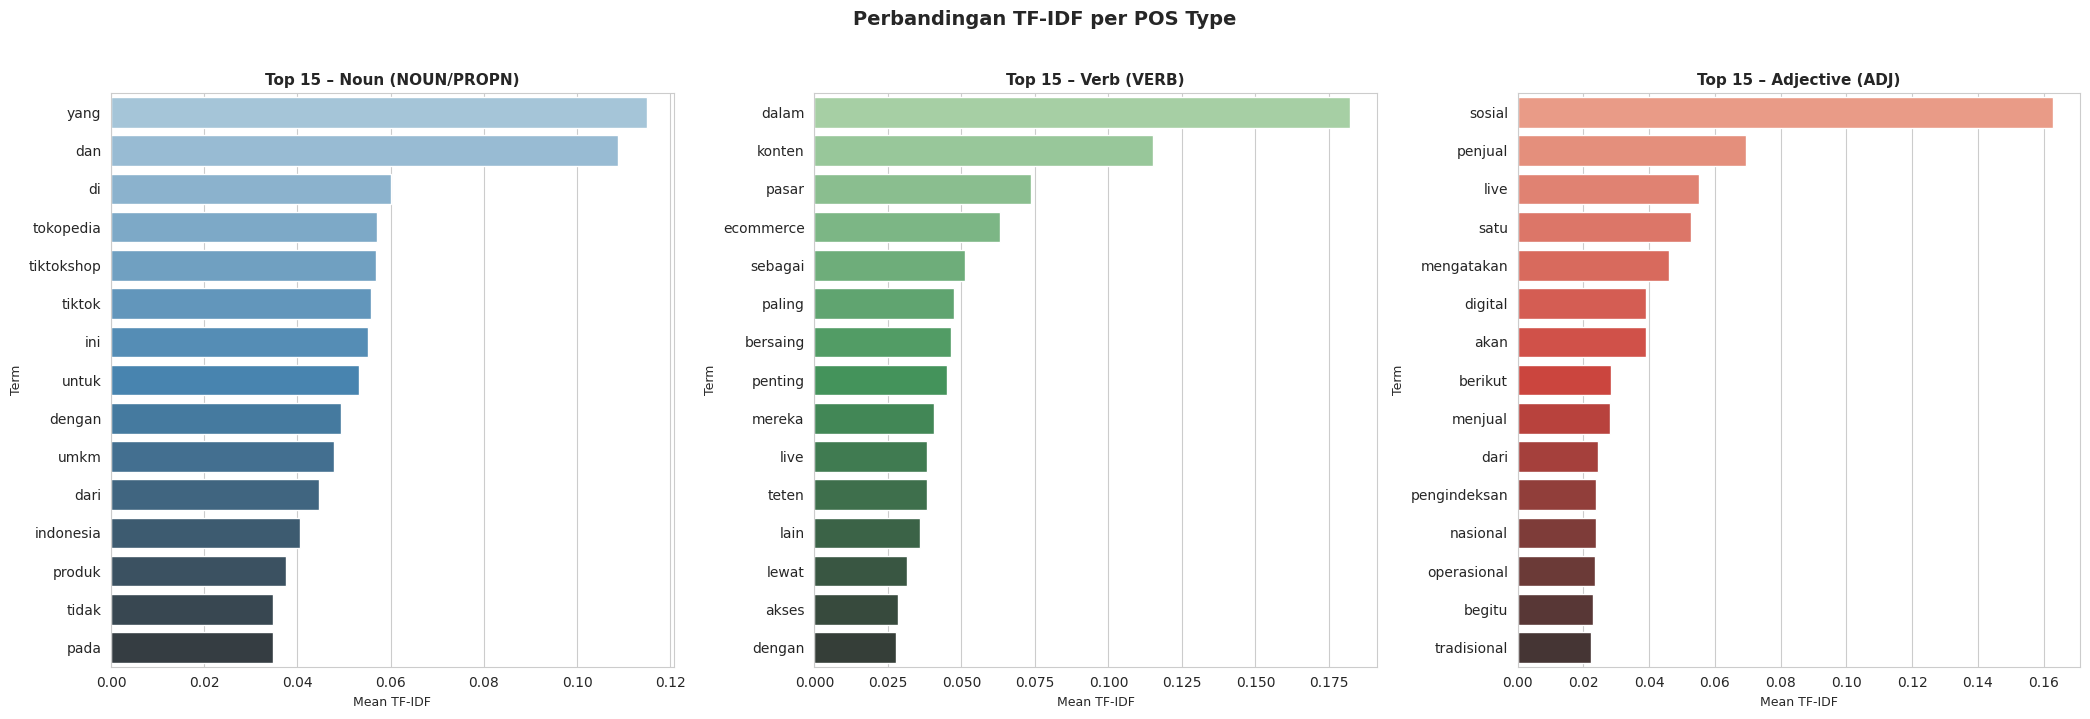

   💾 Gambar: /content/figures/tfidf_pos_comparison.png


In [13]:
# Visualisasi Perbandingan POS (Side-by-side)
print('📊 Visualisasi perbandingan top term Noun vs Verb vs ADJ...')

if pos_results and len(pos_results) >= 2:
    n_pos = len(pos_results)
    fig, axes = plt.subplots(1, n_pos, figsize=(7 * n_pos, 7))
    if n_pos == 1:
        axes = [axes]

    palettes = ['Blues_d', 'Greens_d', 'Reds_d']
    for i, (top_pos, ax) in enumerate(zip(pos_results, axes)):
        pos_label = top_pos['pos_type'].iloc[0]
        df_plot = top_pos.head(15)
        sns.barplot(y='term', x='mean_tfidf', data=df_plot,
                    palette=palettes[i % len(palettes)], ax=ax, orient='h')
        ax.set_title(f'Top 15 – {pos_label}', fontsize=11, fontweight='bold')
        ax.set_xlabel('Mean TF-IDF', fontsize=9)
        ax.set_ylabel('Term', fontsize=9)

    plt.suptitle('Perbandingan TF-IDF per POS Type', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('/content/figures/tfidf_pos_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    print('   💾 Gambar: /content/figures/tfidf_pos_comparison.png')

---
## 6️⃣ TF-IDF dengan NER Analysis (Named Entity Recognition)

📊 TF-IDF + NER ANALYSIS
Menjalankan NER (Named Entity Recognition)...


100%|██████████| 200/200 [00:15<00:00, 13.26it/s]


Total entitas ditemukan: 11200


,entity,label,freq
3404,indonesia,GPE,572
5861,lebih,GPE,290
10743,yang,PERSON,198
294,akan,ORG,174
3897,juga,ORG,161
9375,serta,GPE,124
1981,dapat,ORG,105
8105,pembeli,NORP,92
2480,dia,ORG,83
8973,sama,GPE,82



✅ Entitas NER disimpan ke: /content/data/ner_entities.csv

Label NER ditemukan: ['GPE', 'PERSON', 'ORG', 'NORP', 'PRODUCT']


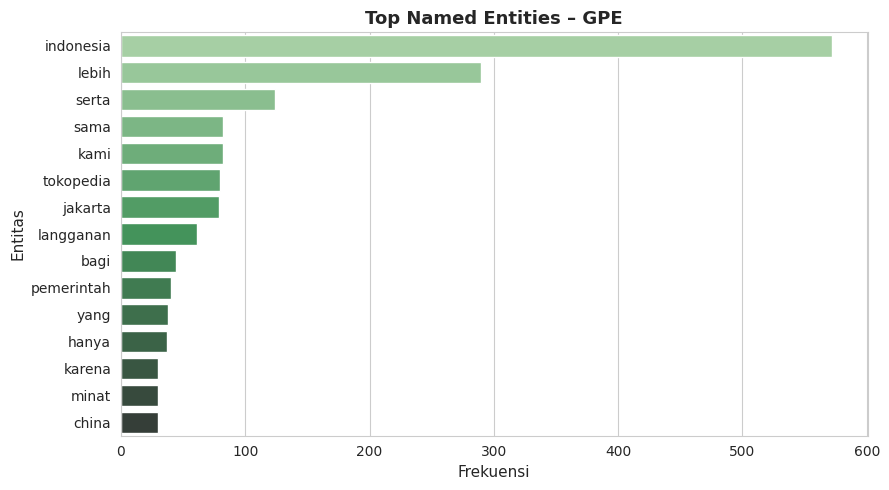

   💾 Gambar: /content/figures/ner_top_gpe.png


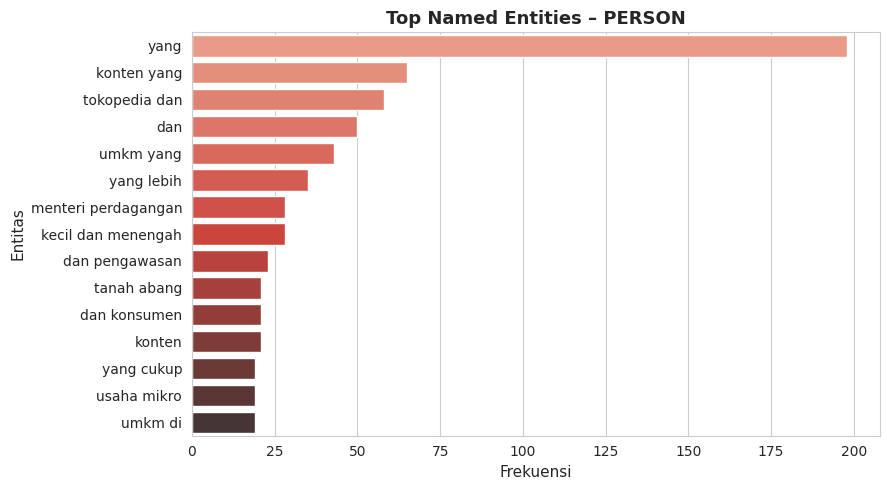

   💾 Gambar: /content/figures/ner_top_person.png


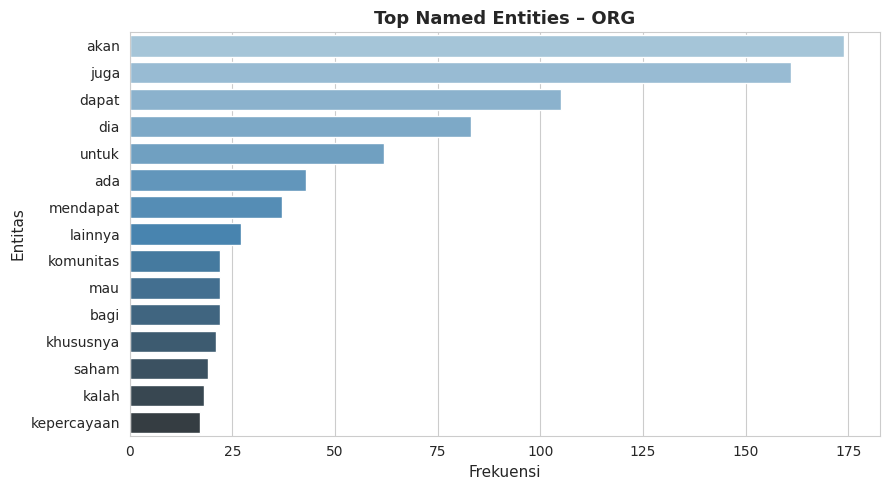

   💾 Gambar: /content/figures/ner_top_org.png


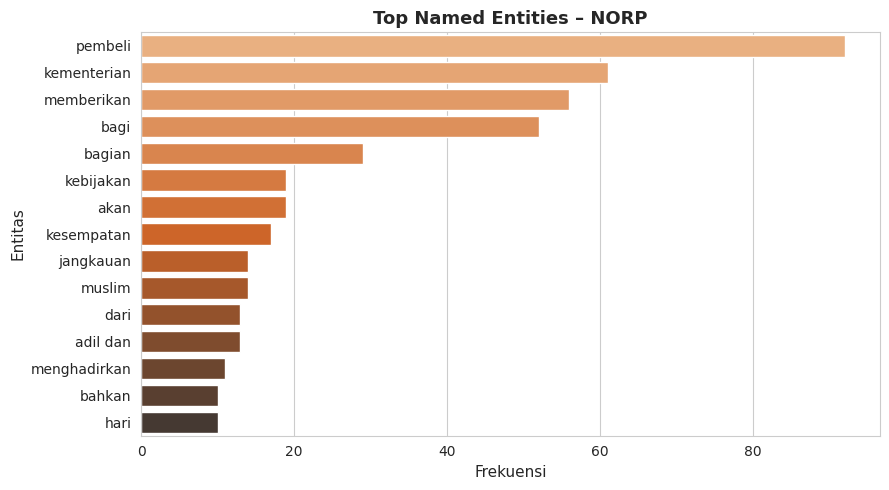

   💾 Gambar: /content/figures/ner_top_norp.png


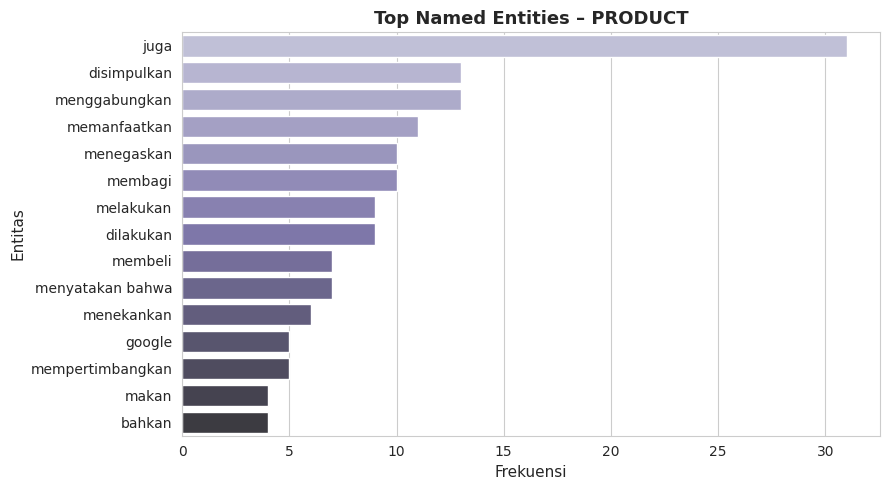

   💾 Gambar: /content/figures/ner_top_product.png


In [14]:
# NER Analysis dari Top TF-IDF Terms
# Identifikasi top terms yang merupakan Named Entities
print('=' * 55)
print('📊 TF-IDF + NER ANALYSIS')
print('=' * 55)

def extract_ner_tokens(text, allowed_labels=('ORG','GPE','PERSON','PRODUCT','NORP')):
    """
    Ekstrak named entities dari teks.
    Label default:
      ORG     = Organisasi/Perusahaan
      GPE     = Negara/Kota
      PERSON  = Nama orang
      PRODUCT = Produk
      NORP    = Kelompok nasional/keagamaan
    """
    if not text or str(text).strip() == '':
        return []
    doc = nlp(str(text)[:500000])
    return [(ent.text.lower(), ent.label_) for ent in doc.ents
            if ent.label_ in allowed_labels and len(ent.text) > 1]

# Proses NER pada sample (gunakan content asli agar lebih akurat)
print('Menjalankan NER (Named Entity Recognition)...')
sample_df2 = df.sample(min(200, len(df)), random_state=42).copy()
corpus_ner  = sample_df2['content_cleaned'].fillna('').astype(str).tolist()

all_entities = []
for text in tqdm(corpus_ner):
    all_entities.extend(extract_ner_tokens(text))

# Buat DataFrame entitas
df_ner = pd.DataFrame(all_entities, columns=['entity','label'])
df_ner_freq = df_ner.groupby(['entity','label']).size().reset_index(name='freq')
df_ner_freq = df_ner_freq.sort_values('freq', ascending=False)

print(f'\nTotal entitas ditemukan: {len(df_ner_freq)}')
display(df_ner_freq.head(20))
df_ner_freq.to_csv('/content/data/ner_entities.csv', index=False)
print('\n✅ Entitas NER disimpan ke: /content/data/ner_entities.csv')

# --- Visualisasi per label ---
ner_labels = df_ner_freq['label'].unique()
print(f'\nLabel NER ditemukan: {list(ner_labels)}')

ner_colors = {'ORG':'Blues_d','GPE':'Greens_d','PERSON':'Reds_d',
               'PRODUCT':'Purples_d','NORP':'Oranges_d'}

for lbl in ner_labels:
    sub = df_ner_freq[df_ner_freq['label'] == lbl].head(15)
    if len(sub) < 2:
        continue
    plt.figure(figsize=(9, 5))
    palette = ner_colors.get(lbl, 'viridis')
    sns.barplot(y='entity', x='freq', data=sub, palette=palette, orient='h')
    plt.title(f'Top Named Entities – {lbl}', fontsize=13, fontweight='bold')
    plt.xlabel('Frekuensi', fontsize=11)
    plt.ylabel('Entitas', fontsize=11)
    plt.tight_layout()
    plt.savefig(f'/content/figures/ner_top_{lbl.lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f'   💾 Gambar: /content/figures/ner_top_{lbl.lower()}.png')

In [15]:
# Cek overlap NER vs Top TF-IDF Terms
# (Berapa banyak top TF-IDF term yang merupakan named entity?)
print('=' * 55)
print('📊 OVERLAP: Top TF-IDF Terms vs Named Entities')
print('=' * 55)

# Ambil top 50 TF-IDF overall
top50 = compute_tfidf_top(corpus_all, top_n=50, ngram_range=(1,1), min_df=3)
tfidf_terms_set = set(top50['term'].str.lower().tolist())

# Named entities yang ada di top TF-IDF
ner_terms_set = set(df_ner_freq['entity'].str.lower().tolist())
overlap = tfidf_terms_set.intersection(ner_terms_set)

print(f'Top 50 TF-IDF terms   : {len(tfidf_terms_set)}')
print(f'Unique NER entities    : {len(ner_terms_set)}')
print(f'Overlap (TF-IDF ∩ NER): {len(overlap)}')
print(f'\nTerm yang merupakan Named Entity sekaligus Top TF-IDF:')
for t in sorted(overlap):
    label = df_ner_freq[df_ner_freq['entity'] == t]['label'].values
    print(f'  - {t:30s} {label}')

# Annotate top50 dengan NER label
def get_ner_label(term):
    rows = df_ner_freq[df_ner_freq['entity'] == term.lower()]
    if len(rows) > 0:
        return rows.iloc[0]['label']
    return '-'

top50['ner_label'] = top50['term'].apply(get_ner_label)
display(top50)
top50.to_csv('/content/data/tfidf_top50_with_ner.csv', index=False)
print('\n✅ Top 50 TF-IDF + NER label disimpan ke: /content/data/tfidf_top50_with_ner.csv')

📊 OVERLAP: Top TF-IDF Terms vs Named Entities
Top 50 TF-IDF terms   : 50
Unique NER entities    : 10888
Overlap (TF-IDF ∩ NER): 14

Term yang merupakan Named Entity sekaligus Top TF-IDF:
  - aplikasi                       ['ORG']
  - beli                           ['ORG' 'NORP']
  - dagang                         ['ORG' 'GPE']
  - digital                        ['ORG']
  - ekonomi                        ['PERSON']
  - harga                          ['PRODUCT' 'ORG']
  - hasil                          ['PERSON']
  - indonesia                      ['GPE']
  - konten                         ['PERSON']
  - langsung                       ['GPE']
  - menteri                        ['PERSON' 'GPE']
  - platform                       ['GPE']
  - tokopedia                      ['GPE']
  - transaksi                      ['GPE']


,term,mean_tfidf,ner_label
0,tiktokshop,0.067954,-
1,tiktok,0.067303,-
2,tokopedia,0.057873,GPE
3,jual,0.057249,-
4,umkm,0.051501,-
5,indonesia,0.048941,GPE
6,dagang,0.047516,ORG
7,produk,0.044067,-
8,usaha,0.042918,-
9,platform,0.037226,GPE



✅ Top 50 TF-IDF + NER label disimpan ke: /content/data/tfidf_top50_with_ner.csv


---
## 7️⃣ N-Grams Analysis (Bigram & Trigram)

📊 N-GRAMS ANALYSIS (1-gram, 2-gram, 3-gram)

🔹 Unigram (1-gram)


,term,mean_tfidf,ngram_type
0,tiktokshop,0.067168,Unigram (1-gram)
1,tiktok,0.066521,Unigram (1-gram)
2,tokopedia,0.057479,Unigram (1-gram)
3,jual,0.056393,Unigram (1-gram)
4,umkm,0.050542,Unigram (1-gram)
5,indonesia,0.048231,Unigram (1-gram)
6,dagang,0.046996,Unigram (1-gram)
7,produk,0.043329,Unigram (1-gram)
8,usaha,0.042128,Unigram (1-gram)
9,platform,0.036718,Unigram (1-gram)


   💾 Gambar: /content/figures/tfidf_unigram.png


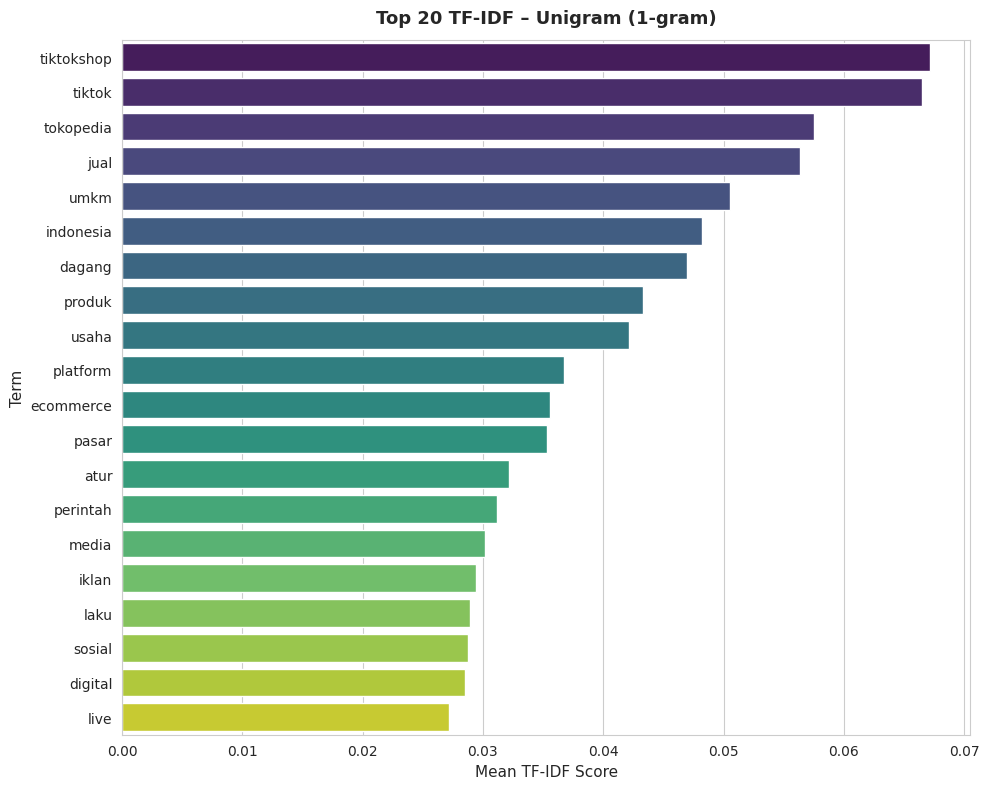


🔹 Bigram  (2-gram)


,term,mean_tfidf,ngram_type
0,media sosial,0.027965,Bigram (2-gram)
1,tokopedia tiktokshop,0.022920,Bigram (2-gram)
2,laku usaha,0.020187,Bigram (2-gram)
3,social commerce,0.019880,Bigram (2-gram)
4,iklan iklan,0.015650,Bigram (2-gram)
5,nyaman iklan,0.015640,Bigram (2-gram)
6,iklan langgan,0.015640,Bigram (2-gram)
7,langgan bisnispro,0.015640,Bigram (2-gram)
8,laku umkm,0.015187,Bigram (2-gram)
9,menteri dagang,0.015133,Bigram (2-gram)


   💾 Gambar: /content/figures/tfidf_bigram.png


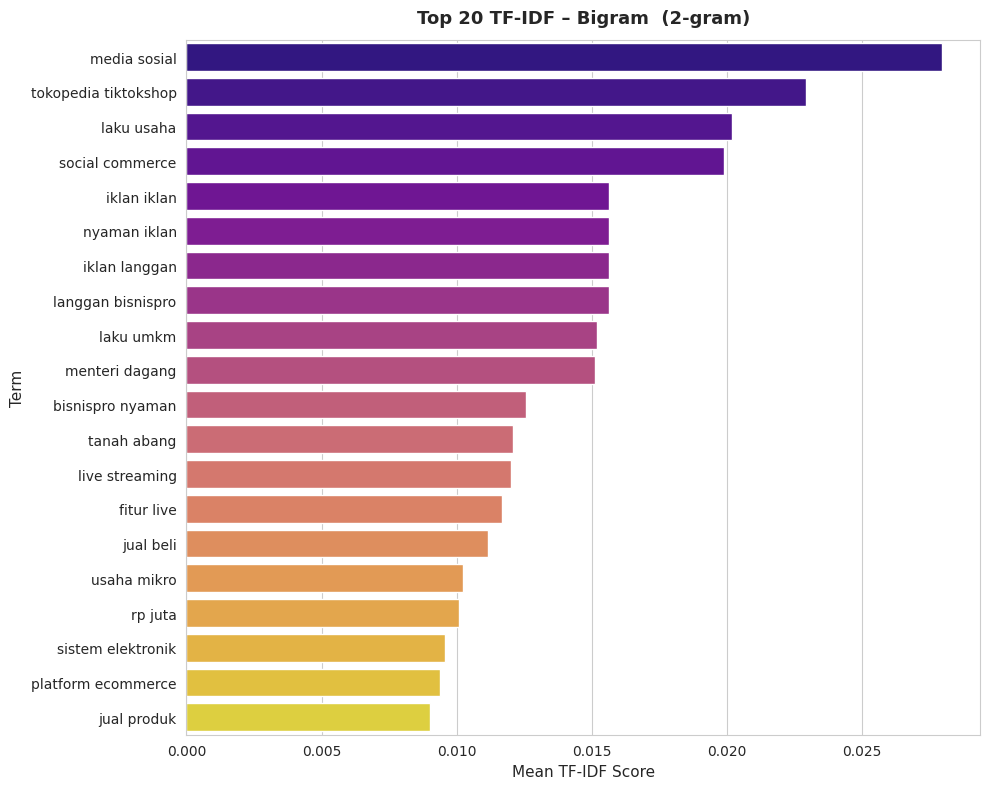


🔹 Trigram (3-gram)


,term,mean_tfidf,ngram_type
0,iklan langgan bisnispro,0.020751,Trigram (3-gram)
1,nyaman iklan langgan,0.020751,Trigram (3-gram)
2,langgan bisnispro nyaman,0.016628,Trigram (3-gram)
3,bisnispro nyaman iklan,0.016628,Trigram (3-gram)
4,usaha mikro tengah,0.012216,Trigram (3-gram)
5,iklan iklan iklan,0.011942,Trigram (3-gram)
6,platform media sosial,0.011027,Trigram (3-gram)
7,tiktokshop by tokopedia,0.010750,Trigram (3-gram)
8,dagang sistem elektronik,0.010333,Trigram (3-gram)
9,pasar tanah abang,0.010227,Trigram (3-gram)


   💾 Gambar: /content/figures/tfidf_trigram.png


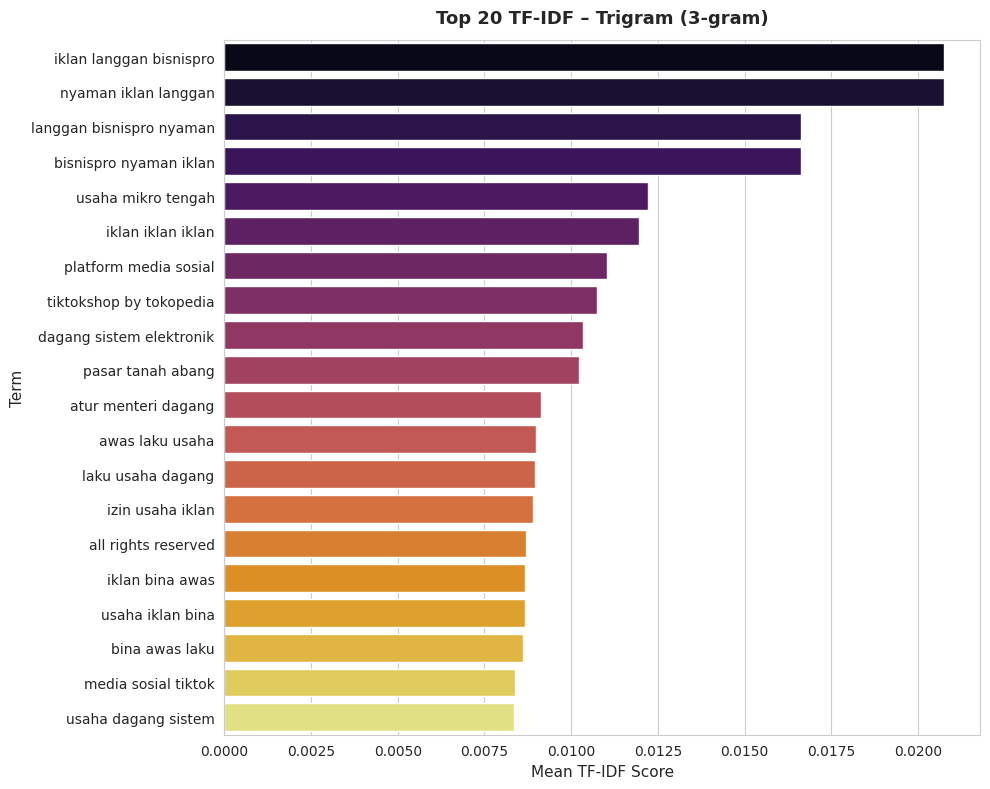


✅ Hasil N-Grams disimpan ke: /content/data/tfidf_ngrams.csv


In [16]:
# N-Grams Analysis (Unigram, Bigram, Trigram)
print('=' * 55)
print('📊 N-GRAMS ANALYSIS (1-gram, 2-gram, 3-gram)')
print('=' * 55)

ngram_configs = [
    ('Unigram (1-gram)' , (1, 1), 'viridis'),
    ('Bigram  (2-gram)' , (2, 2), 'plasma'),
    ('Trigram (3-gram)' , (3, 3), 'inferno'),
]

ngram_results = []
for label, ngrange, palette in ngram_configs:
    print(f'\n🔹 {label}')
    top_ng = compute_tfidf_top(
        corpus_all, top_n=25, ngram_range=ngrange,
        min_df=2, max_features=10000
    )
    top_ng['ngram_type'] = label.strip()
    ngram_results.append(top_ng)
    display(top_ng.head(10))
    slug = label.split()[0].lower()
    plot_tfidf(top_ng, f'Top 20 TF-IDF – {label}',
               fig_path=f'/content/figures/tfidf_{slug}.png',
               top_n=20, color=palette)

if ngram_results:
    df_ngram_all = pd.concat(ngram_results, ignore_index=True)
    df_ngram_all.to_csv('/content/data/tfidf_ngrams.csv', index=False)
    print('\n✅ Hasil N-Grams disimpan ke: /content/data/tfidf_ngrams.csv')

📊 Visualisasi perbandingan Unigram vs Bigram vs Trigram...


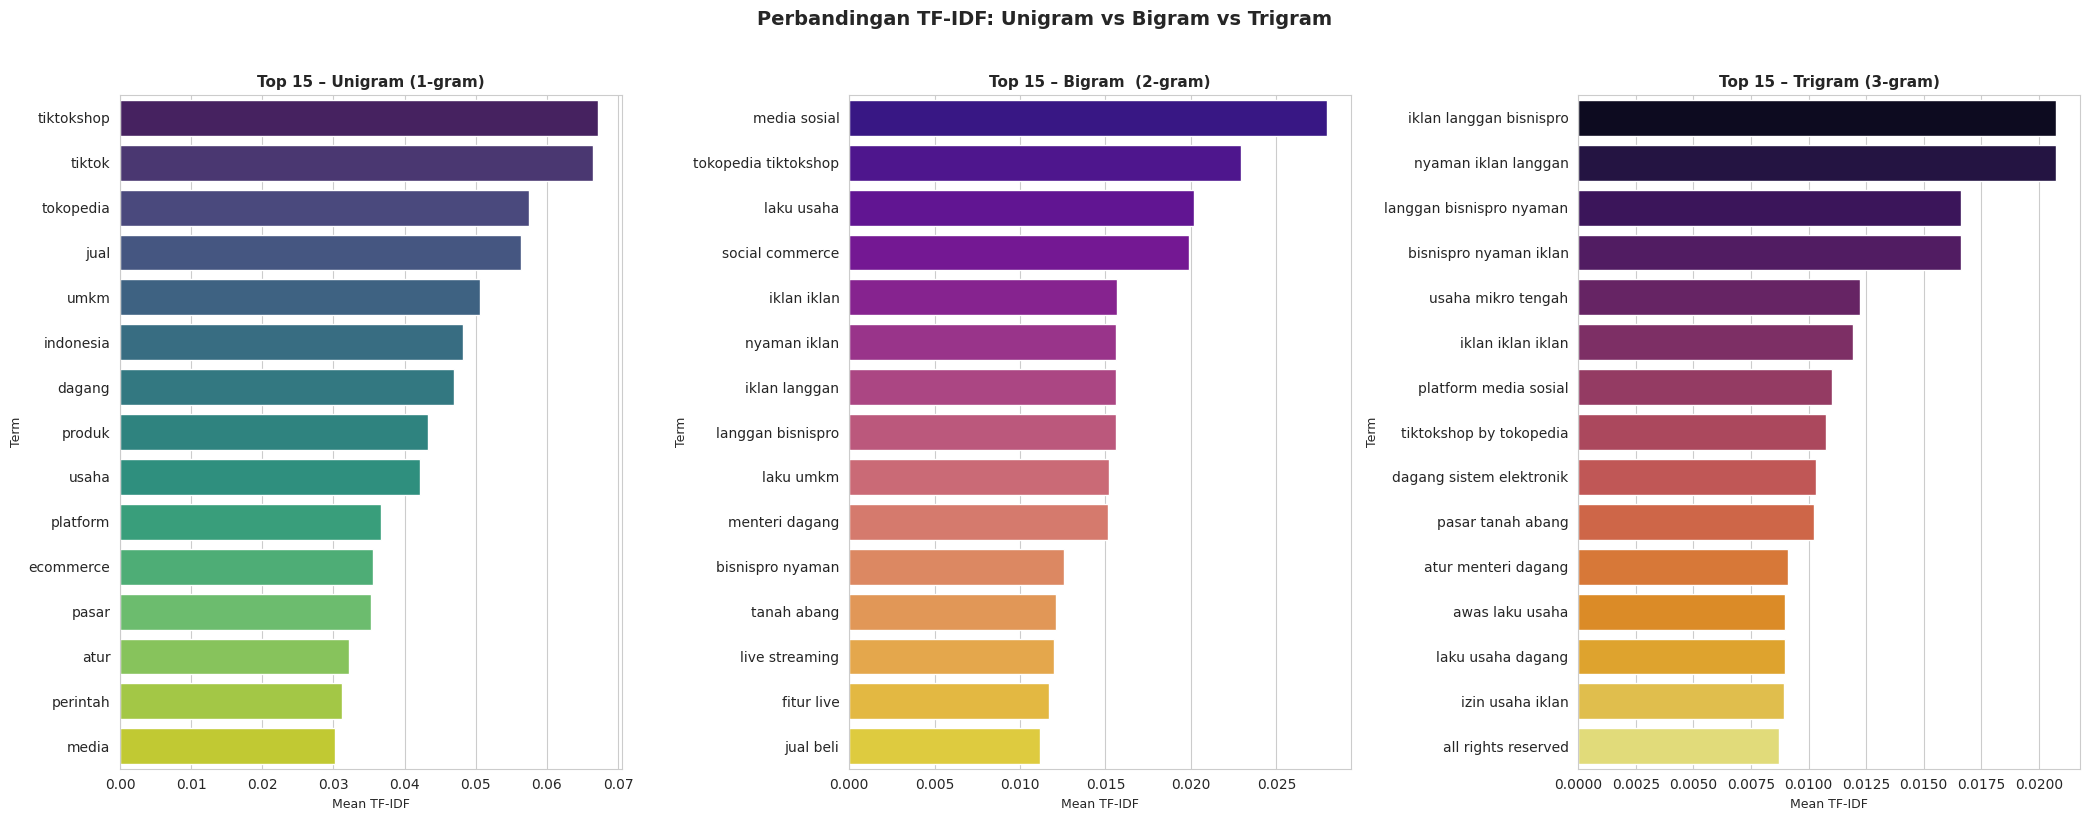

   💾 Gambar: /content/figures/tfidf_ngrams_comparison.png


In [17]:
# Visualisasi Perbandingan N-Grams (side-by-side)
print('📊 Visualisasi perbandingan Unigram vs Bigram vs Trigram...')

if ngram_results:
    fig, axes = plt.subplots(1, 3, figsize=(21, 8))
    palettes = ['viridis', 'plasma', 'inferno']

    for i, (top_ng, ax) in enumerate(zip(ngram_results, axes)):
        lbl = top_ng['ngram_type'].iloc[0]
        df_plot = top_ng.head(15)
        sns.barplot(y='term', x='mean_tfidf', data=df_plot,
                    palette=palettes[i], ax=ax, orient='h')
        ax.set_title(f'Top 15 – {lbl}', fontsize=11, fontweight='bold')
        ax.set_xlabel('Mean TF-IDF', fontsize=9)
        ax.set_ylabel('Term', fontsize=9)

    plt.suptitle('Perbandingan TF-IDF: Unigram vs Bigram vs Trigram',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('/content/figures/tfidf_ngrams_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    print('   💾 Gambar: /content/figures/tfidf_ngrams_comparison.png')

In [18]:
# Bigram per Kategori (bonus analisis)
print('=' * 55)
print('📊 BIGRAM per KATEGORI')
print('=' * 55)

bigram_cat_results = []
for cat in sorted(categories):
    subset = df[df['category'] == cat][TEXT_COL].fillna('').astype(str).tolist()
    if len(subset) < 5:
        continue
    top_bi_cat = compute_tfidf_top(subset, top_n=10, ngram_range=(2,2), min_df=2)
    top_bi_cat['category'] = cat
    bigram_cat_results.append(top_bi_cat)
    print(f'\n🔹 Bigram – {cat}:')
    display(top_bi_cat.head(5))

if bigram_cat_results:
    df_bigram_cat = pd.concat(bigram_cat_results, ignore_index=True)
    df_bigram_cat.to_csv('/content/data/tfidf_bigram_per_kategori.csv', index=False)
    print('\n✅ Bigram per kategori disimpan ke: /content/data/tfidf_bigram_per_kategori.csv')

📊 BIGRAM per KATEGORI

🔹 Bigram – Bisnis:


,term,mean_tfidf,category
0,media sosial,0.037538,Bisnis
1,laku usaha,0.025142,Bisnis
2,laku umkm,0.023888,Bisnis
3,tokopedia tiktokshop,0.021943,Bisnis
4,iklan iklan,0.018893,Bisnis



🔹 Bigram – Edukasi:


,term,mean_tfidf,category
0,media sosial,0.033225,Edukasi
1,live streaming,0.032225,Edukasi
2,laku usaha,0.029101,Edukasi
3,tokopedia tiktokshop,0.026867,Edukasi
4,jual beli,0.026625,Edukasi



🔹 Bigram – Event:


...


🔹 Bigram – Regulasi:


,term,mean_tfidf,category
0,media sosial,0.041622,Regulasi
1,social commerce,0.037411,Regulasi
2,iklan iklan,0.027426,Regulasi
3,laku usaha,0.025993,Regulasi
4,menteri dagang,0.025086,Regulasi



🔹 Bigram – Strategi:


,term,mean_tfidf,category
0,tokopedia tiktokshop,0.044930,Strategi
1,media sosial,0.036589,Strategi
2,laku usaha,0.028402,Strategi
3,laku umkm,0.025566,Strategi
4,rp juta,0.024401,Strategi



✅ Bigram per kategori disimpan ke: /content/data/tfidf_bigram_per_kategori.csv


---
## 📋 Ringkasan Output

In [20]:
# Ringkasan semua output yang dihasilkan
import glob

print('=' * 60)
print('✅ RINGKASAN OUTPUT TF-IDF ANALYSIS')
print('=' * 60)

csv_files = sorted(glob.glob('/content/data/tfidf_*.csv') + glob.glob('/content/data/ner_*.csv'))
img_files = sorted(glob.glob('/content/figures/tfidf_*.png') + glob.glob('/content/figures/ner_*.png'))

print(f'\n📁 File CSV ({len(csv_files)} file):')
for f in csv_files:
    size = os.path.getsize(f) / 1024
    print(f'   {f:60s} ({size:.1f} KB)')

print(f'\n🖼️  File Gambar ({len(img_files)} file):')
for f in img_files:
    size = os.path.getsize(f) / 1024
    print(f'   {f:60s} ({size:.1f} KB)')

print('TF-IDF selesai!')

✅ RINGKASAN OUTPUT TF-IDF ANALYSIS

📁 File CSV (11 file):
   /content/data/ner_entities.csv                               (310.4 KB)
   /content/data/tfidf_bigram_per_kategori.csv                  (2.5 KB)
   /content/data/tfidf_ngrams.csv                               (3.8 KB)
   /content/data/tfidf_overall_bigram.csv                       (1.0 KB)
   /content/data/tfidf_overall_unigram.csv                      (0.8 KB)
   /content/data/tfidf_per_bulan.csv                            (2.3 KB)
   /content/data/tfidf_per_kategori.csv                         (4.1 KB)
   /content/data/tfidf_per_kuartal.csv                          (12.4 KB)
   /content/data/tfidf_per_sumber.csv                           (4.8 KB)
   /content/data/tfidf_pos_analysis.csv                         (2.5 KB)
   /content/data/tfidf_top50_with_ner.csv                       (1.5 KB)

🖼️  File Gambar (25 file):
   /content/figures/ner_top_gpe.png                             (44.1 KB)
   /content/figures/ner_top_norp.p